In [1]:
import pandas as pd
import os
import numpy as np
import ast
import collections
from pygenomeviz import GenomeViz
import ast
import pysam

In [2]:
myDF2=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZNames_PSV.csv").set_index("Unnamed: 0")
myDF2['end']=[int(x.split("-")[1]) for x in myDF2.index]
myDF2['sample']=[x.split("_")[0] for x in myDF2['contig']]
goodDAZ = [x.split("_")[0] for x in set(myDF2['contig'])]

In [3]:
len(goodDAZ)

100

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,   
    "svg.fonttype": "none"  
})

mpl.rcParams["font.family"] = "Arial"

In [5]:
colorDict={'DAZ1_EXON1':'pink',
    'DAZ1_EXON2-7-12':'lightblue',
            'DAZ1_EXON3-8-13':'black',
            'DAZ1_EXON4-9-14':'red',
            'DAZ1_EXON5-10-15':'green',
            'DAZ1_EXON6-11-16':'purple',
           'DAZ1_EXON17':'yellow',
            'DAZ1_EXON18':'yellow',
           'DAZ1_EXON19':'yellow',
           'DAZ1_EXON20-22':'yellow',
           'DAZ1_EXON21':'yellow',
           'DAZ1_EXON23':'yellow',
           'DAZ1_EXON24':'yellow',
           'DAZ1_EXON25':'yellow',
           'DAZ1_EXON26':'lime',
           'DAZ1_EXON27':'grey',
           'DAZ1_EXON28':'blue',   
}

In [6]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [7]:
from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [8]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [9]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

In [10]:
for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [11]:
#QC checked good AZFc regions
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [12]:
hgsvc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_07162025.csv')
hprc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HPRC_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_06162025.csv')
ceph = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/CEPH_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_09092025.csv')


dazDFCEPH = ceph[ceph['geneName']=='DAZ1'].copy()
dazDFCEPH['Consortia']="CEPH"
dazDFCEPH['contigStart']=dazDFCEPH['contigStart'].astype(int)
dazDFCEPH['contigEnd']=dazDFCEPH['contigEnd'].astype(int)
dazDFCEPH.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHGSVC = hgsvc[hgsvc['geneName']=='DAZ1'].copy()
dazDFHGSVC['Consortia']="HGSVC"
dazDFHGSVC['contigStart']=dazDFHGSVC['contigStart'].astype(int)
dazDFHGSVC['contigEnd']=dazDFHGSVC['contigEnd'].astype(int)
dazDFHGSVC.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHPRC = hprc[hprc['geneName']=='DAZ1'].copy()
dazDFHPRC['Consortia']="HPRC"
dazDFHPRC['contigStart']=dazDFHPRC['contigStart'].astype(int)
dazDFHPRC['contigEnd']=dazDFHPRC['contigEnd'].astype(int)
dazDFHPRC.sort_values(by=['contig','contigStart'], inplace=True)

In [13]:
combinedDAZ0 = pd.concat([dazDFHPRC,dazDFHGSVC,dazDFCEPH])
combinedDAZ1 = combinedDAZ0[~combinedDAZ0['contig'].str.contains("random")].copy()
combinedDAZ = combinedDAZ1[combinedDAZ1['sampleName'].isin(set(errDF['sample']))].copy()

print(len(combinedDAZ1))
print(len(combinedDAZ))
combinedDAZ.reset_index(inplace=True)

505
382


In [14]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [15]:
good_samples = [s for s in phylogeneticOrder if s in goodDAZ]

sampleCombinations = [
    [a, b]
    for a, b in zip(good_samples, good_samples[1:])
]

In [16]:
len(sampleCombinations)

99

## Mine for Kmers

In [17]:
def revcomp(seq: str) -> str:
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return seq.translate(comp)[::-1]

In [18]:
def generate_kmers(seq: str, k: int):
    if k <= 0:
        raise ValueError("k must be a positive integer.")
    if k > len(seq):
        return set()

    seq = seq.upper()
    revSeq = revcomp(seq)
    kmers = {seq[i:i+k] for i in range(len(seq) - k + 1)}
    revKmers = {revSeq[i:i+k] for i in range(len(revSeq) - k + 1)}

    uniqueKmers = {}
    for x in kmers:
        if x in uniqueKmers:
            continue
        else:
            uniqueKmers[x]=1

    for y in revKmers:
        if y in uniqueKmers:
            continue
        else:
            uniqueKmers[y]=1
            
    return uniqueKmers

In [19]:
sampleCoordinates={}
sampleCoordinatesnonUnique={}
sampleDAZDictUnique={}
sampleDAZDictNonUnique={}
sampleCoordinatesList=[]

for sample in phylogeneticOrder:
    if sample in goodDAZ:
        sampleCoordinates[sample] = {}
        sampleCoordinatesnonUnique[sample] = {}
        tempDict = {}

        tempDF = combinedDAZ[combinedDAZ['sampleName'] == sample].copy()

        for row in tempDF.index:
            geneCoordinate = (
                f"{tempDF.at[row,'contig']}:{tempDF.at[row,'contigStart']}-"
                f"{tempDF.at[row,'contigEnd']}"
            )
            sampleCoordinatesList.append(geneCoordinate)

            sequence = ''.join(
                pysam.faidx(assemblyDict[sample], geneCoordinate).split()[1:]
            )
            uniqueKmers = generate_kmers(sequence, 100)

            for kmer in uniqueKmers:
                if kmer in tempDict:
                    tempDict[kmer].append(geneCoordinate)
                else:
                    tempDict[kmer] = [geneCoordinate]

            sampleCoordinates[sample][geneCoordinate] = 0
            sampleCoordinatesnonUnique[sample][geneCoordinate] = 0

        tempDict2 = {}          
        nonUniqueTempDict = {}  

        for kmer, geneList in tempDict.items():
            if len(geneList)>=2:
                nonUniqueTempDict[kmer]=geneList
                for x in geneList:
                    sampleCoordinatesnonUnique[sample][x]+=1
            
            elif len(geneList)==1:
                tempDict2[kmer]=geneList[0]
                sampleCoordinates[sample][geneList[0]]+=1

            else:
                continue
                
        sampleDAZDictUnique[sample]=tempDict2
        sampleDAZDictNonUnique[sample]=nonUniqueTempDict
               

In [20]:
from tqdm import tqdm
gcLists=[]
uniqueLists=[]

for combo in tqdm(sampleCombinations):
    topSample=combo[0]
    bottomSample=combo[1]
    uniquenewDF = pd.DataFrame(0,index=sampleCoordinates[bottomSample], columns=sampleCoordinates[topSample])
    GCDF = pd.DataFrame(0,index=sampleCoordinates[bottomSample], columns=sampleCoordinates[topSample])

    for kmer in sampleDAZDictUnique[topSample]:
        if kmer in sampleDAZDictUnique[bottomSample]:
            uniquenewDF.at[sampleDAZDictUnique[bottomSample][kmer], sampleDAZDictUnique[topSample][kmer]]+=1
            #newDF.at[sampleDAZDictUnique[bottomSample][kmer], sampleDAZDictUnique[topSample][kmer]]+=1/sampleCoordinates[topSample][sampleDAZDictUnique[topSample][kmer]]
        else:
            continue

    for column in uniquenewDF.columns:
        for gene in uniquenewDF.index:
            uniqueLists.append([column, gene, uniquenewDF.at[gene,column]])
    
    
    for kmer in sampleDAZDictUnique[topSample]:
        if kmer in sampleDAZDictNonUnique[bottomSample]:
            for geneCoordinate in sampleDAZDictNonUnique[bottomSample][kmer]:
                GCDF.at[geneCoordinate, sampleDAZDictUnique[topSample][kmer]]+=1
        else:
            continue

    for column in GCDF.columns:
        for gene in GCDF.index:
            gcLists.append([column, gene, GCDF.at[gene,column]])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:16<00:00,  6.19it/s]


In [21]:
finalUniqueDF = pd.DataFrame(data=uniqueLists)
finalGCDF = pd.DataFrame(data=gcLists)

In [22]:
interestingGenes=[]
for gene in set(finalUniqueDF[0]):
    tempDF = finalUniqueDF[finalUniqueDF[0]==gene].copy()
    if len(tempDF[tempDF[2]>0]) >1:
        interestingGenes.append(gene)
    else:
        continue

In [23]:
genePSVDict = {x:myDF2.at[x,'MaxCount'] for x in myDF2.index}

In [24]:
len(set(finalUniqueDF[finalUniqueDF[0].isin(interestingGenes)][0]))

54

In [25]:
from dna_features_viewer import GraphicFeature, GraphicRecord
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

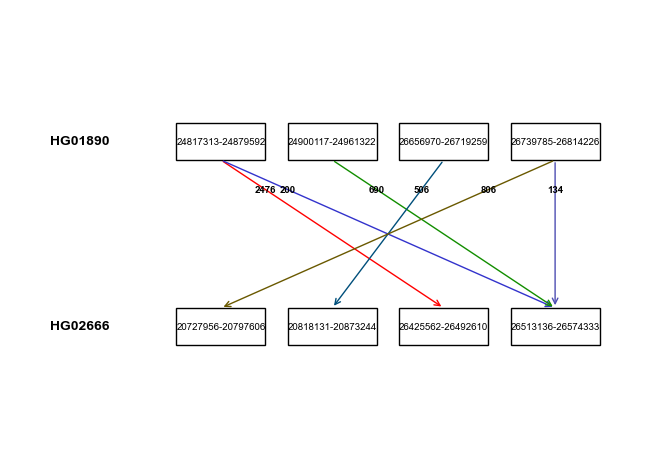

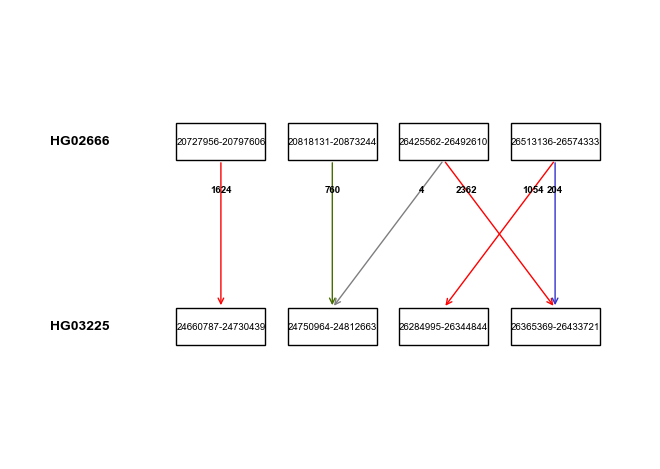

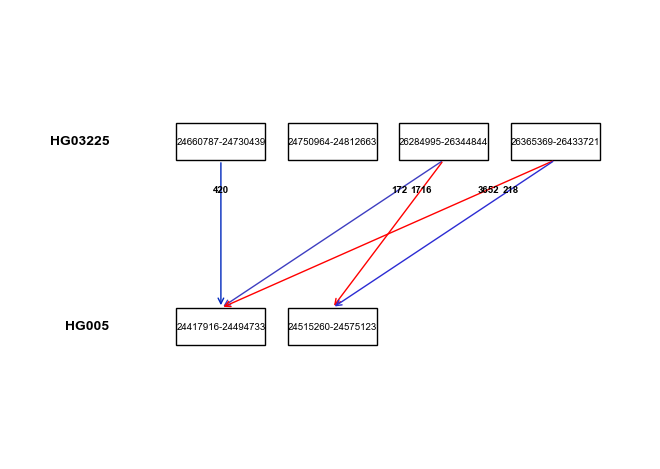

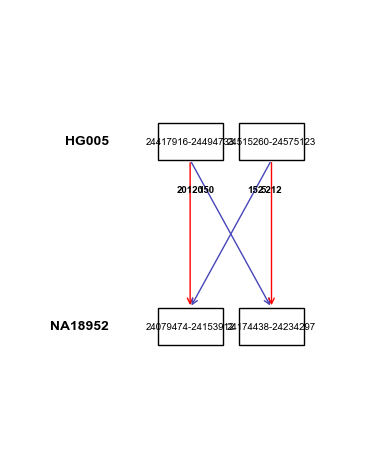

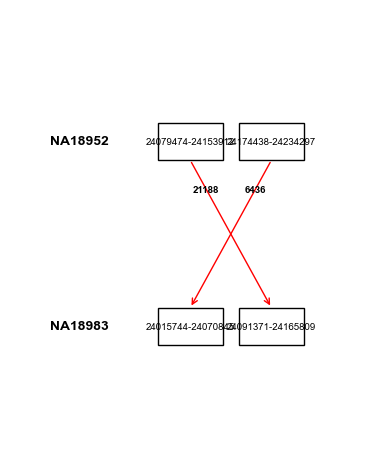

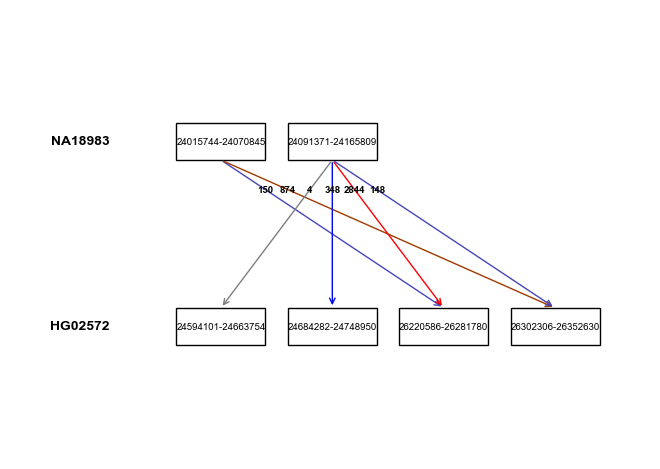

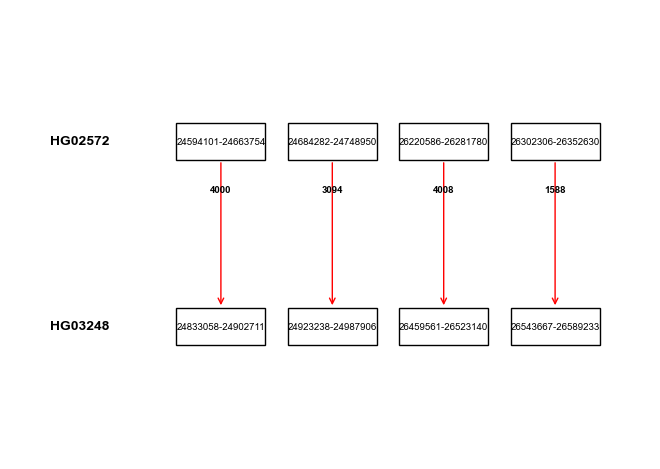

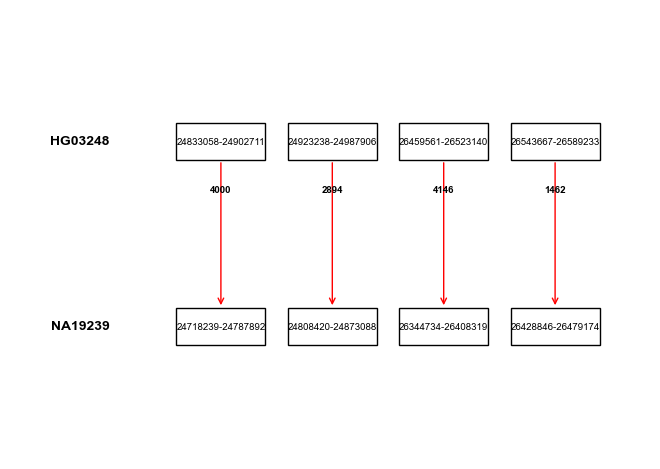

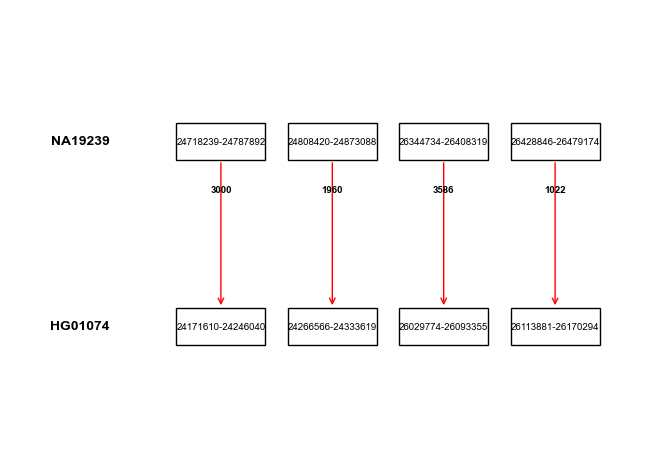

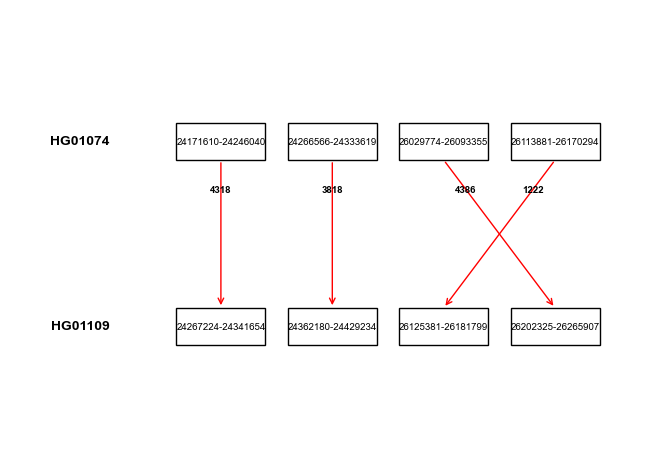

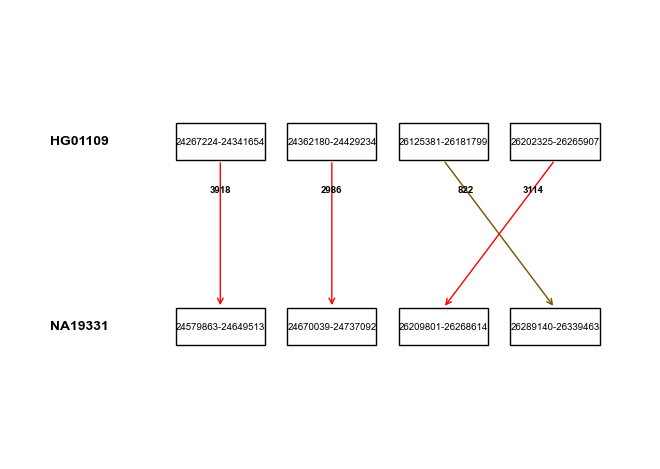

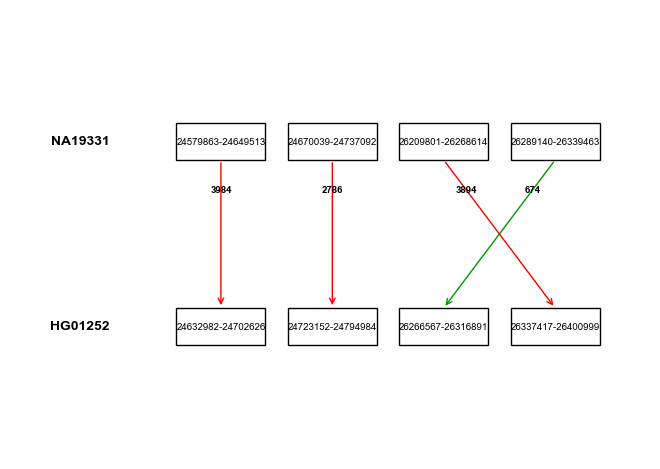

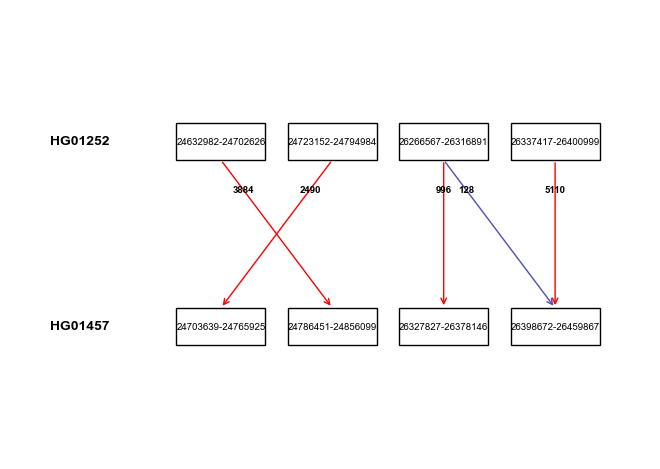

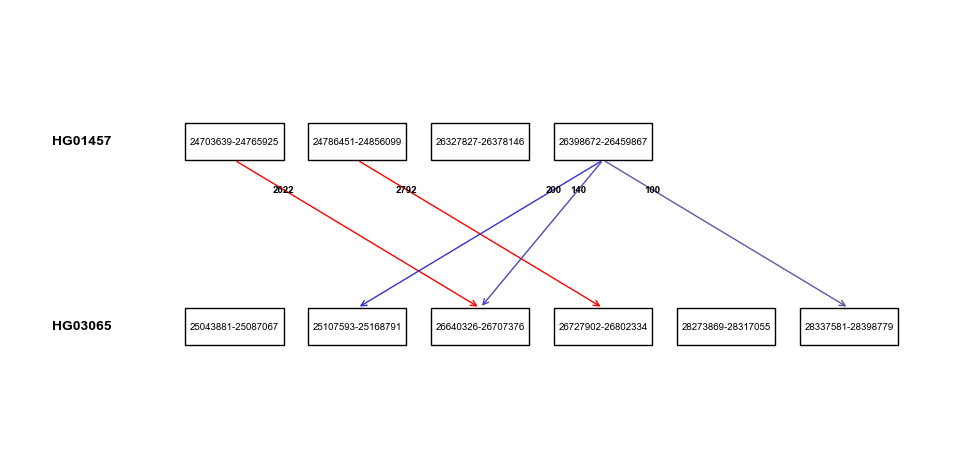

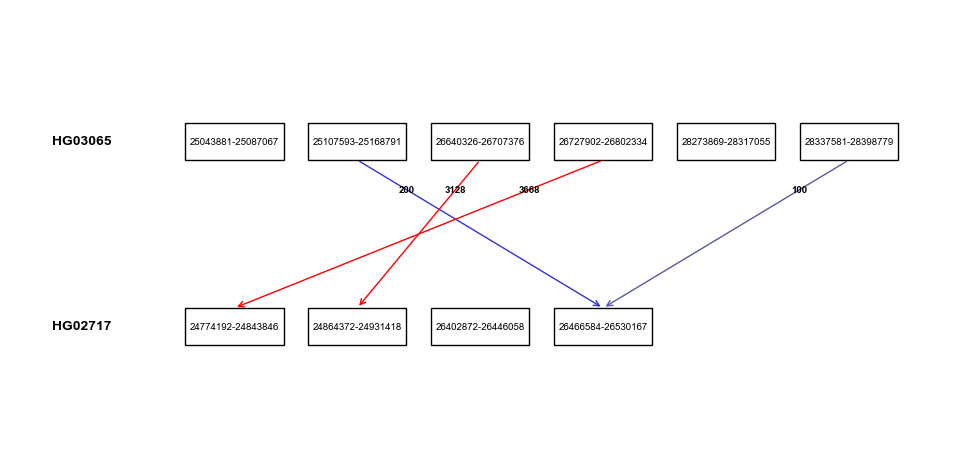

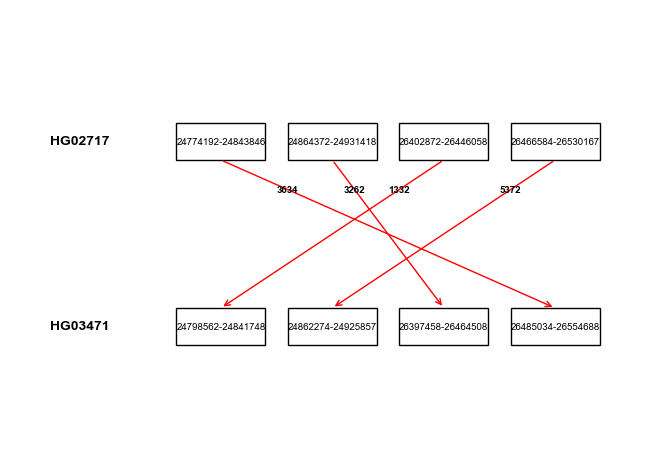

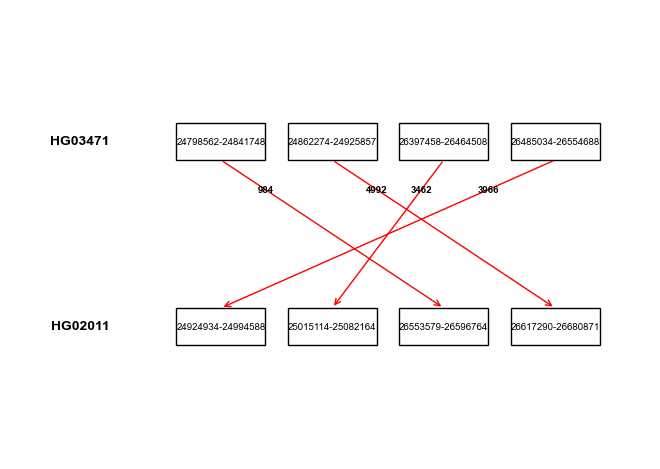

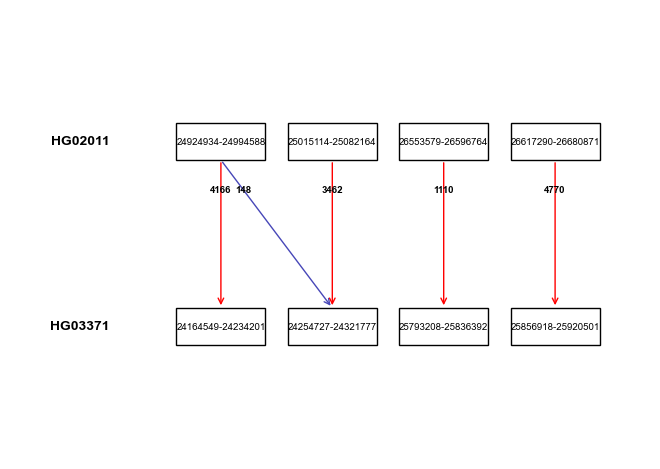

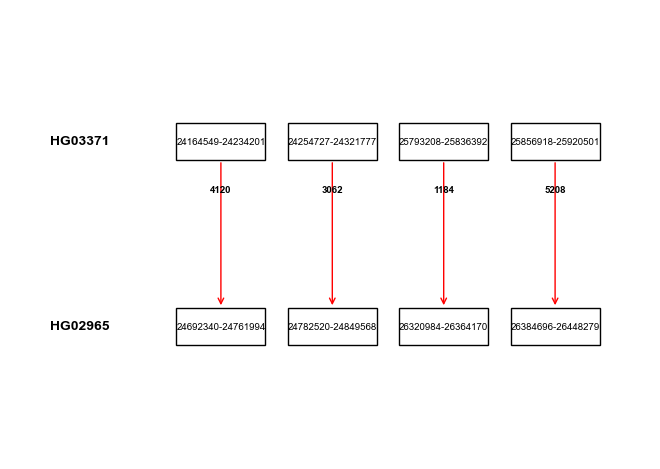

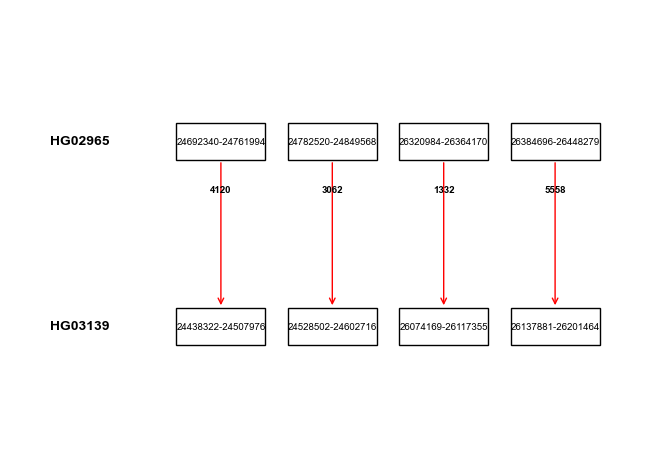

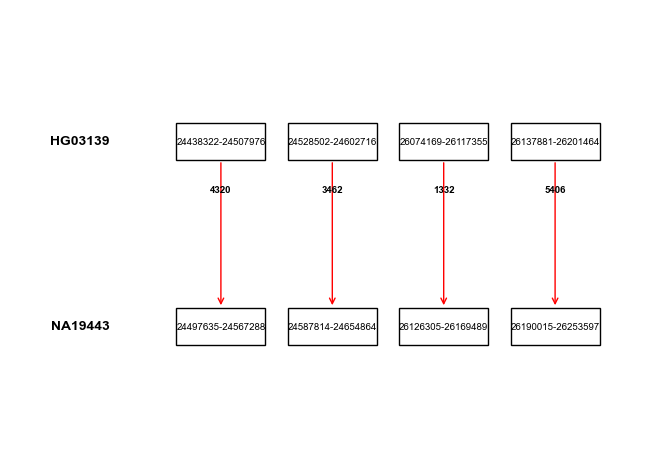

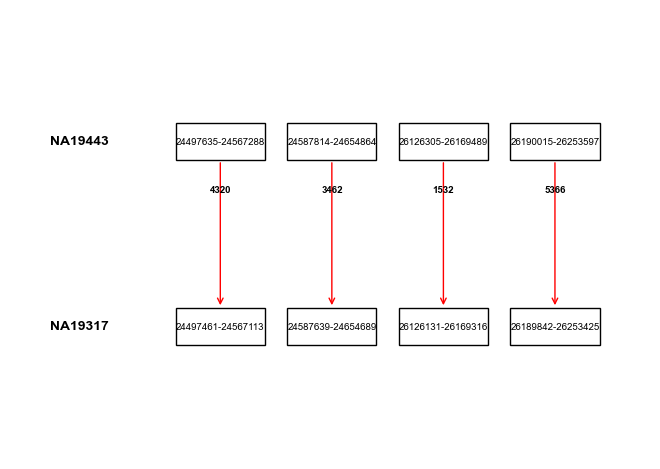

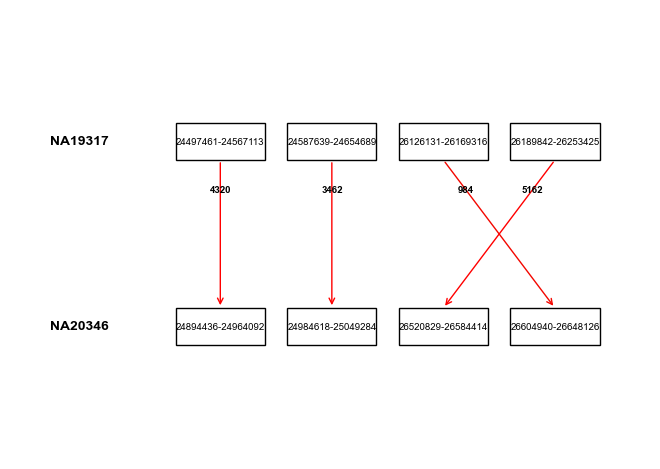

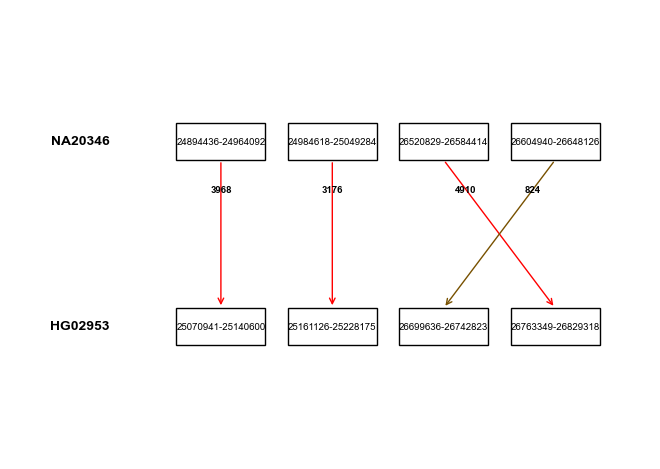

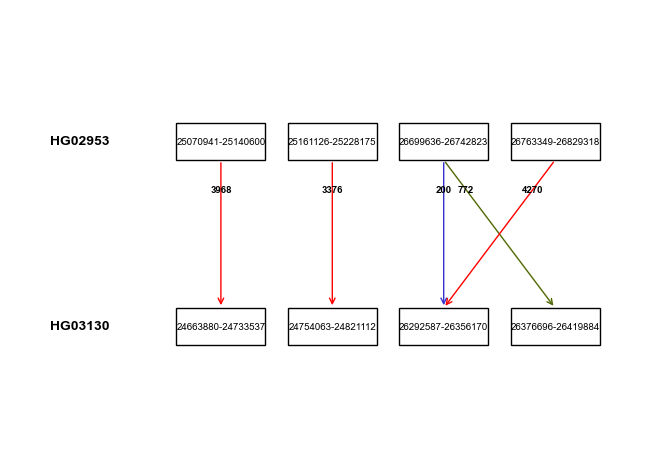

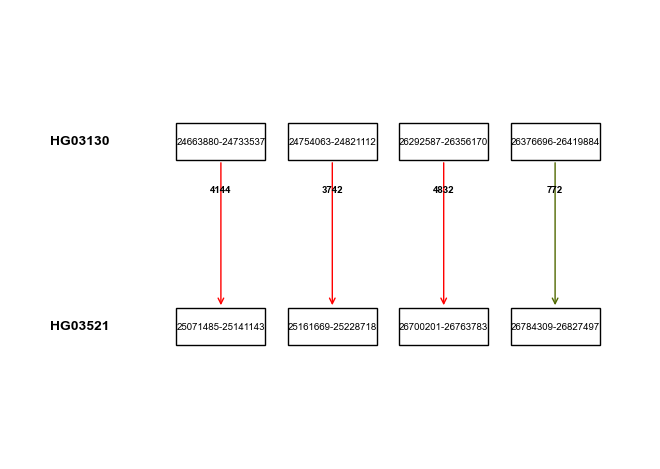

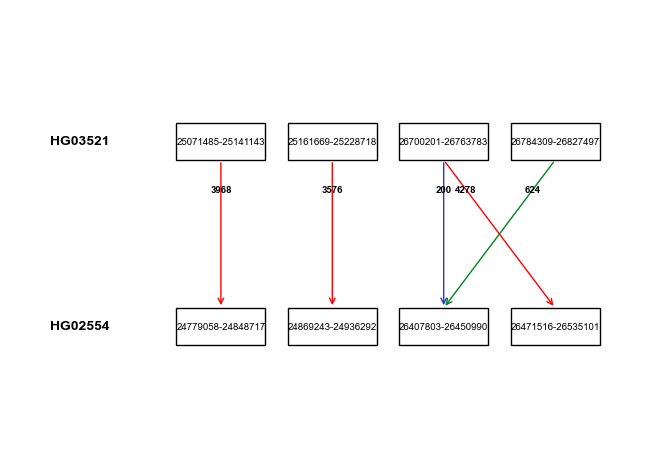

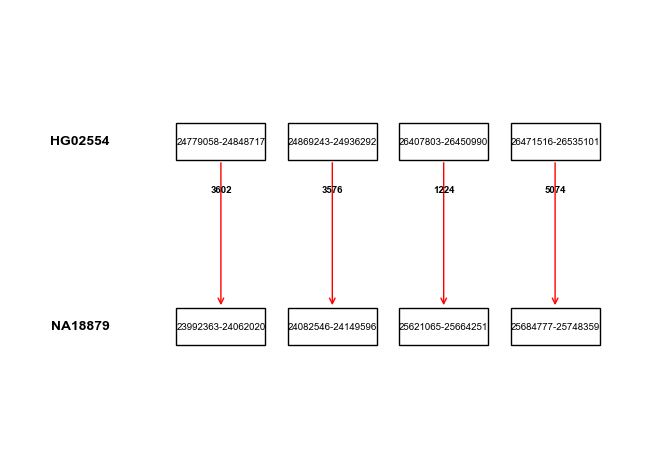

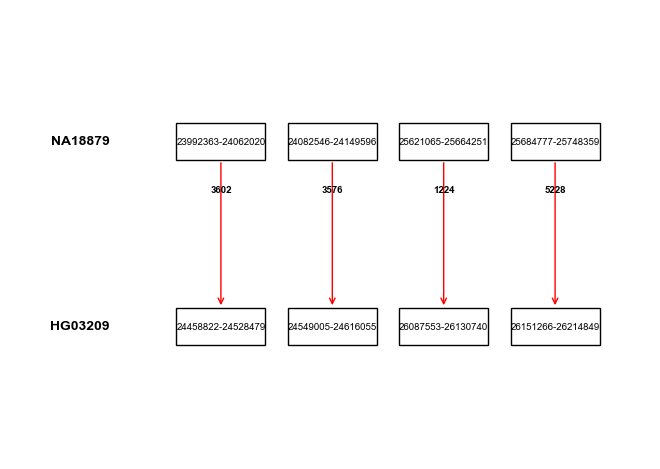

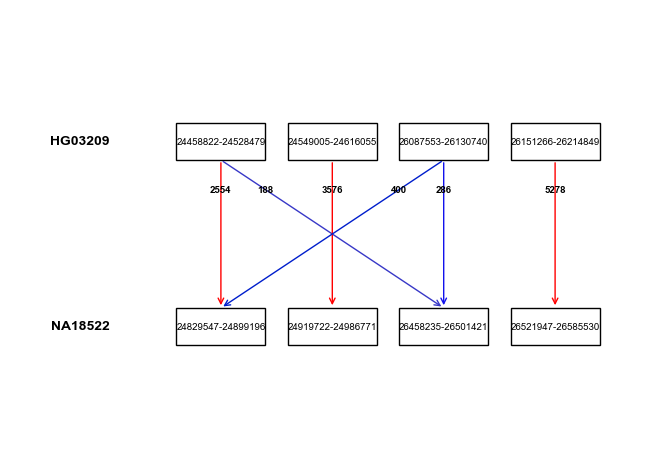

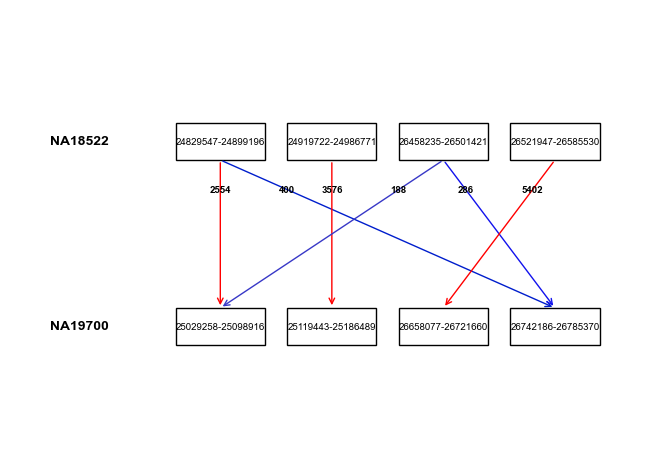

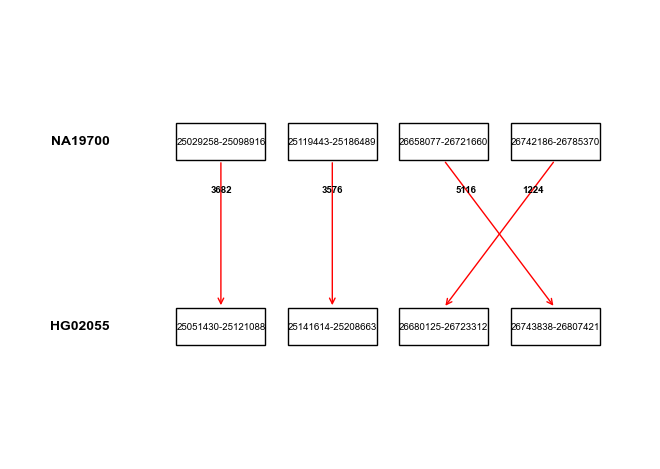

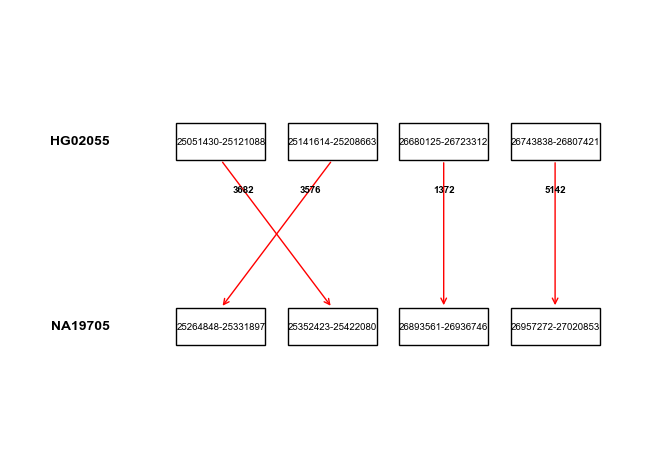

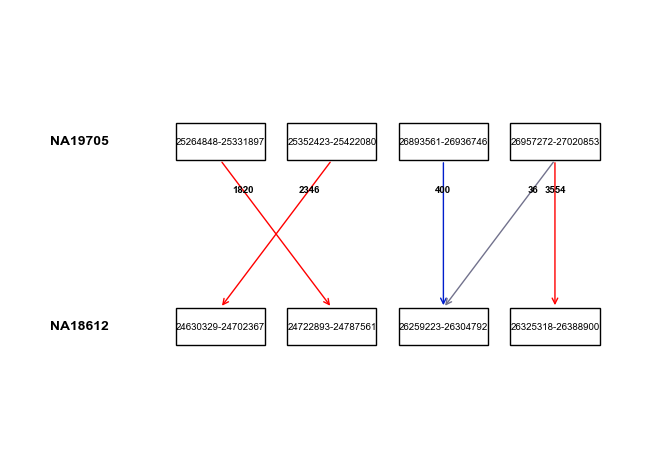

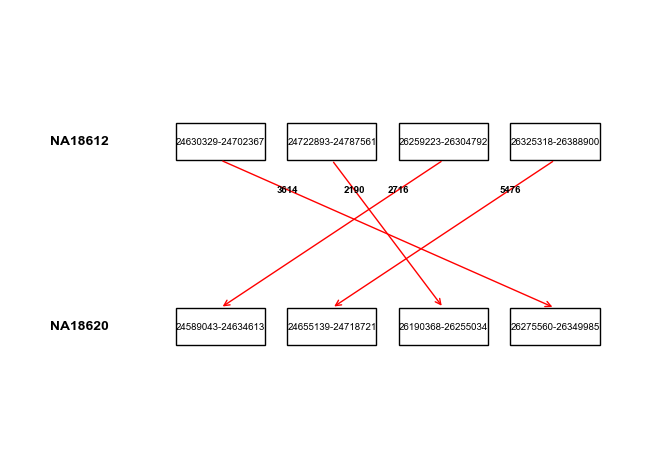

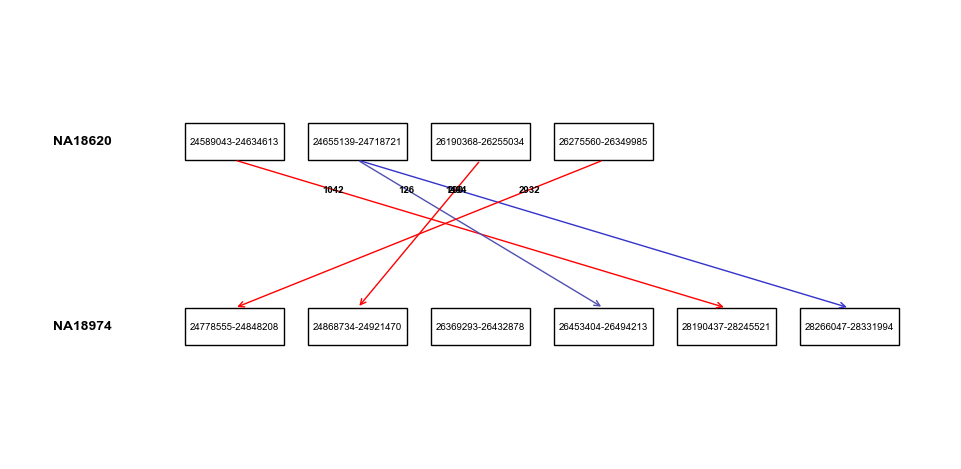

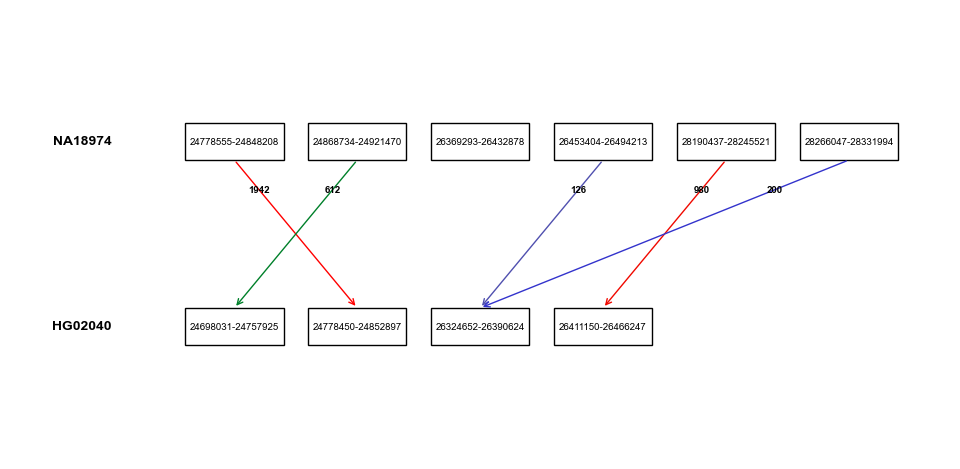

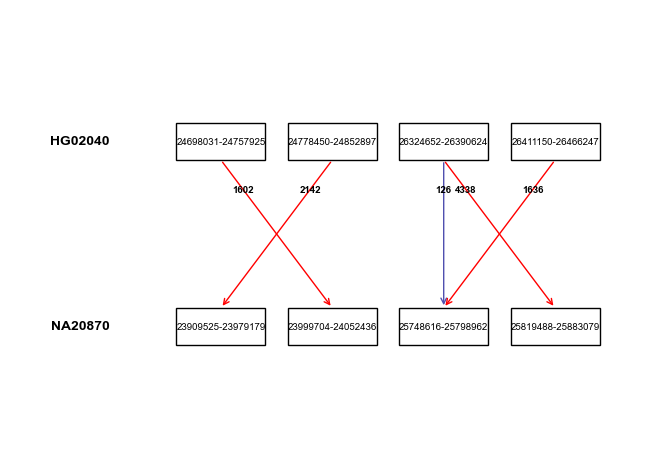

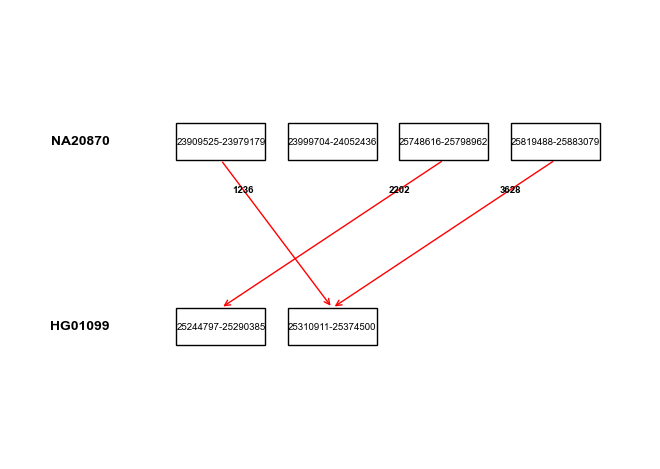

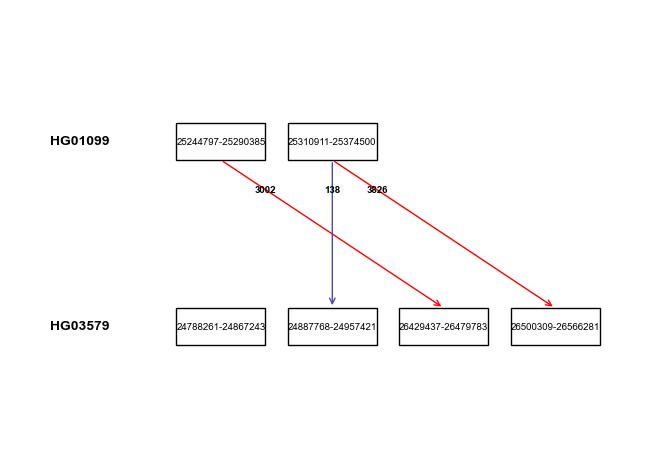

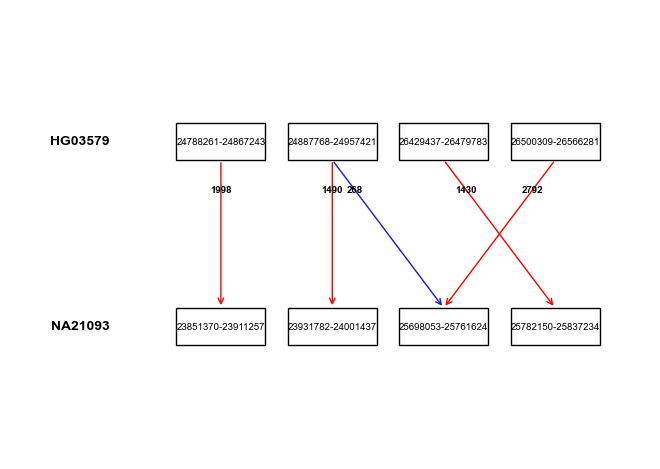

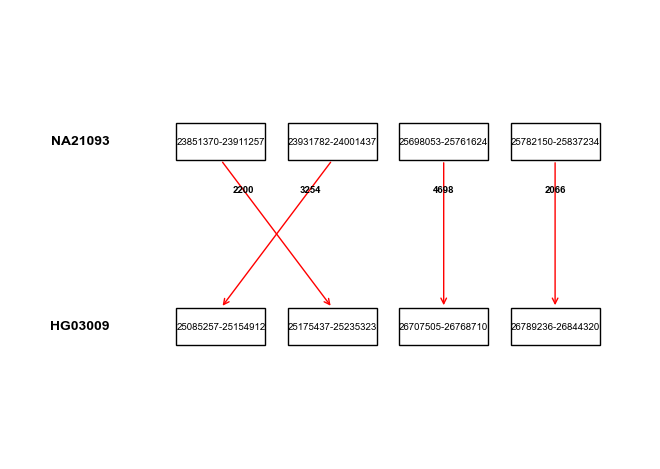

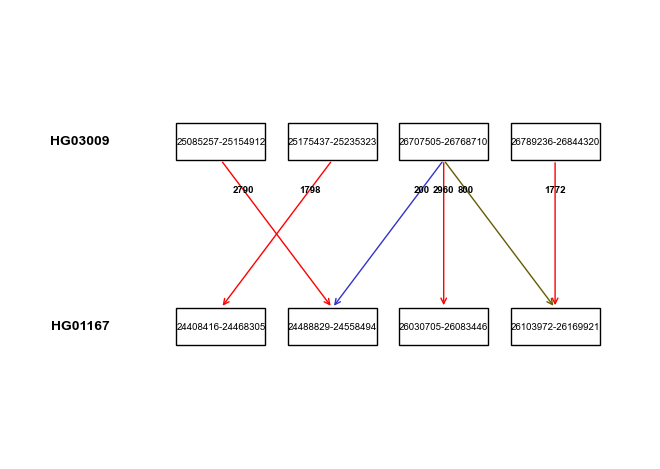

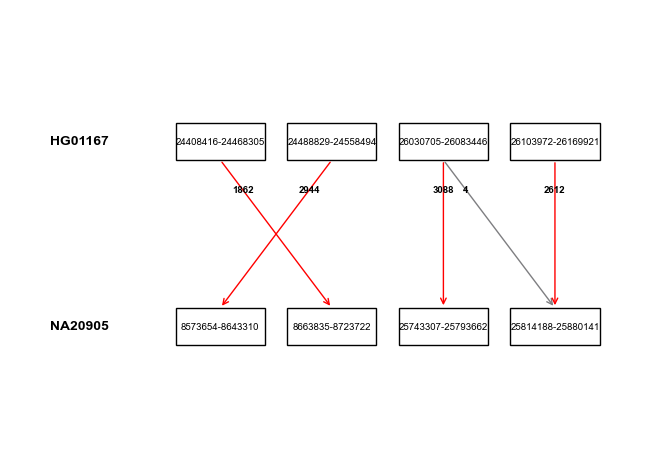

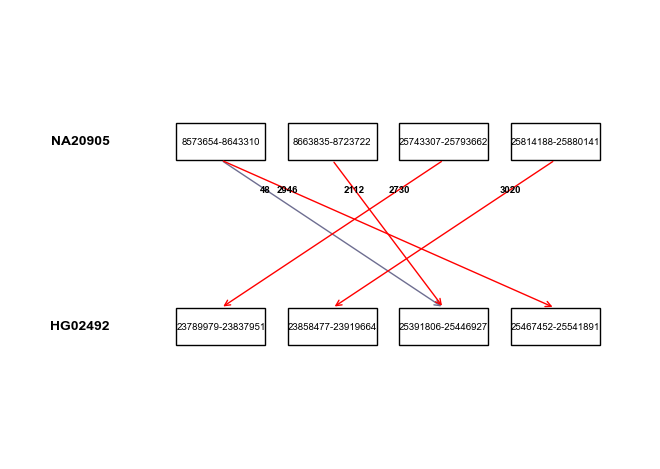

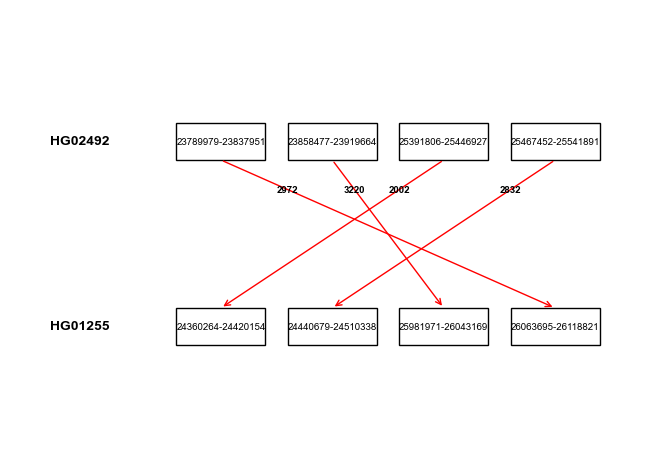

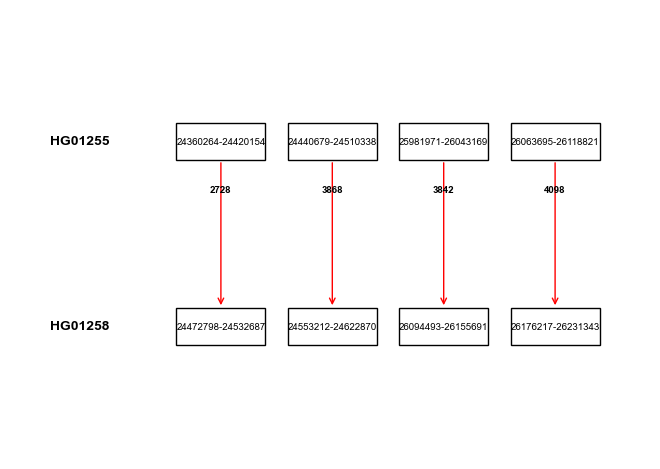

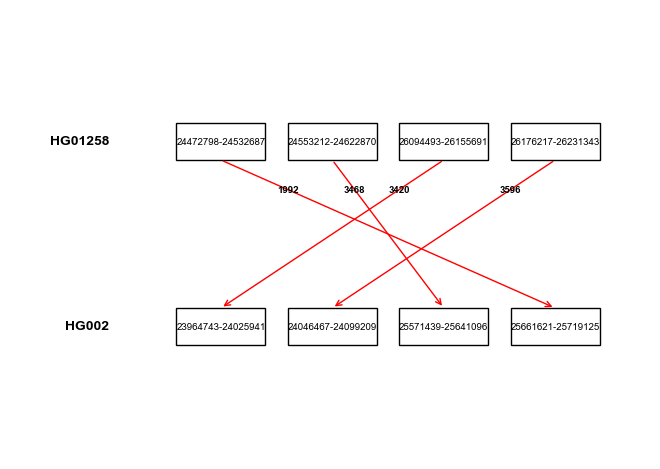

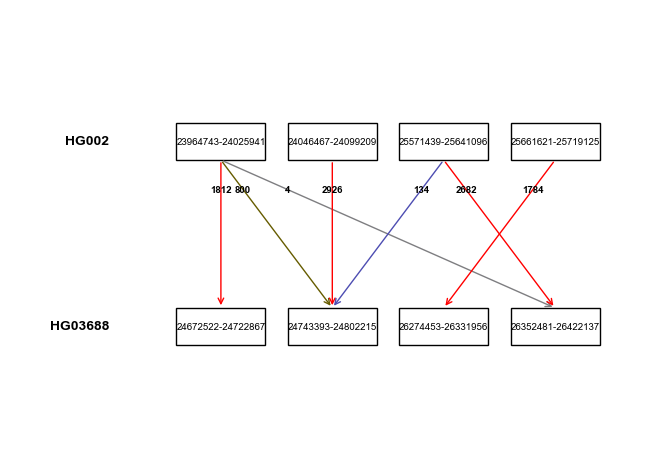

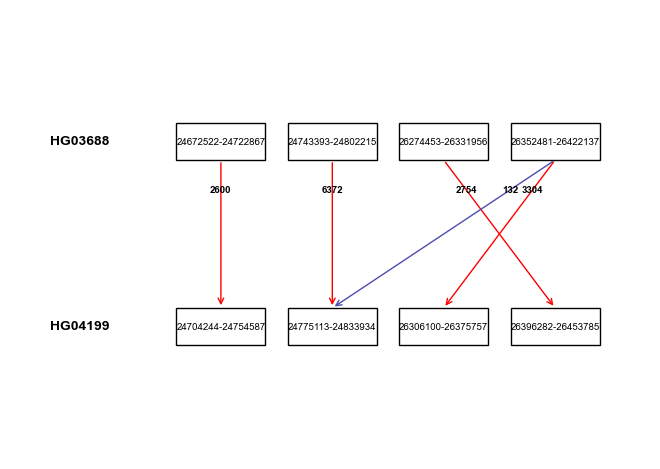

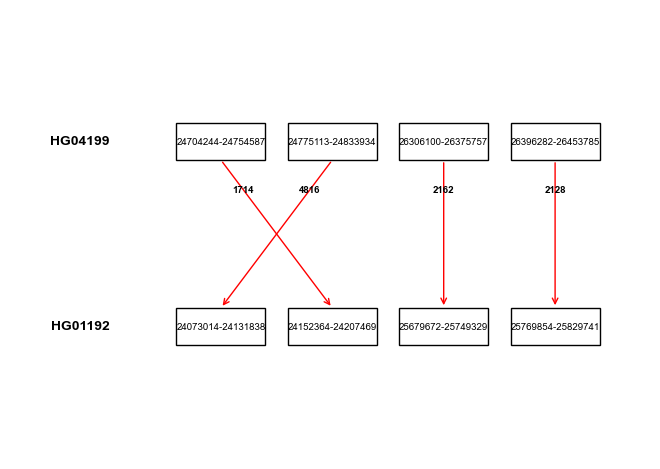

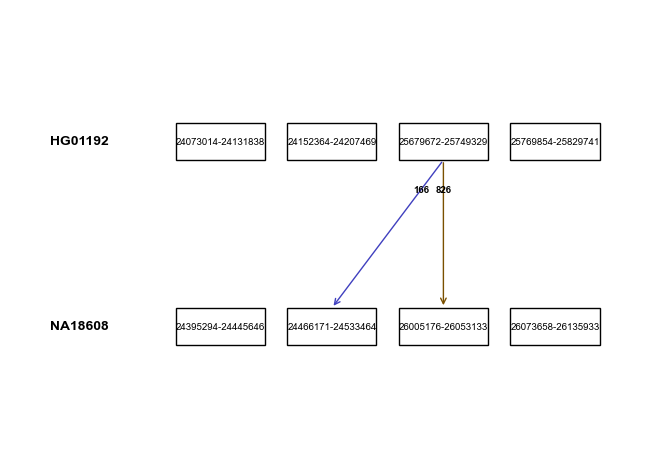

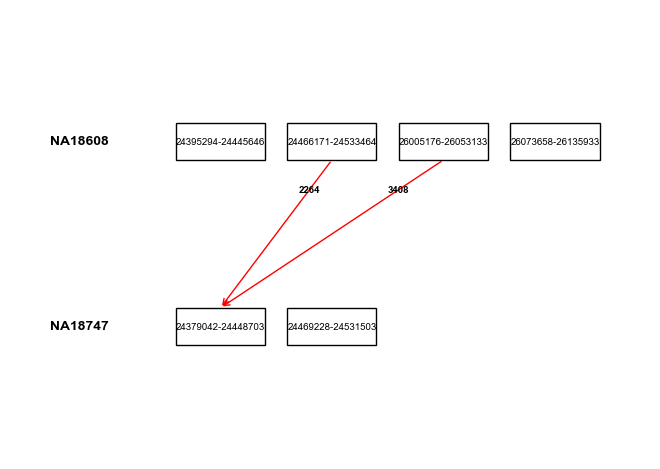

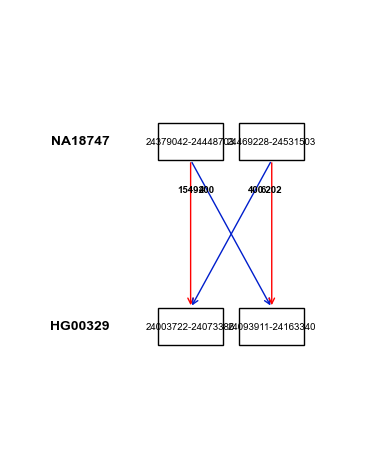

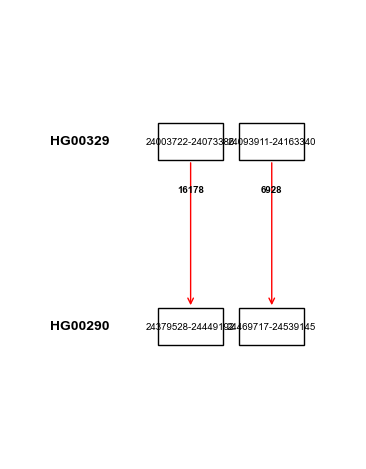

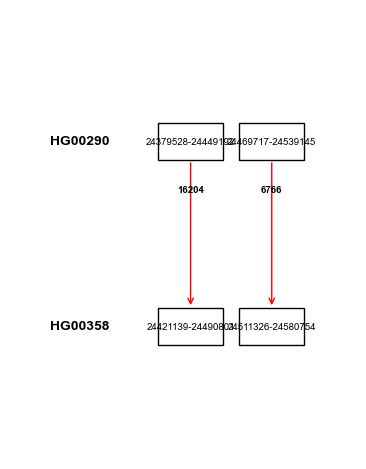

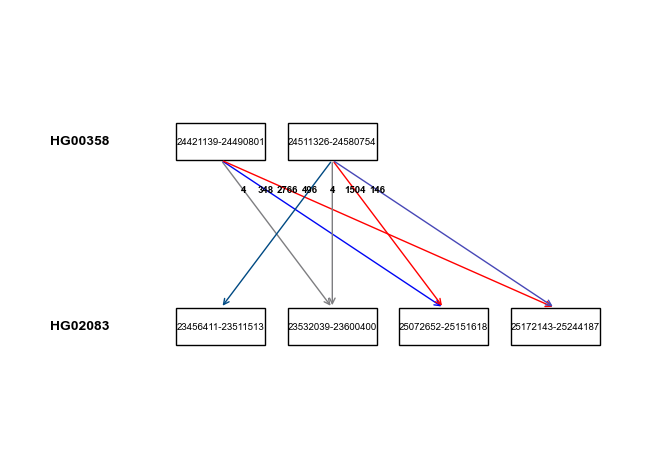

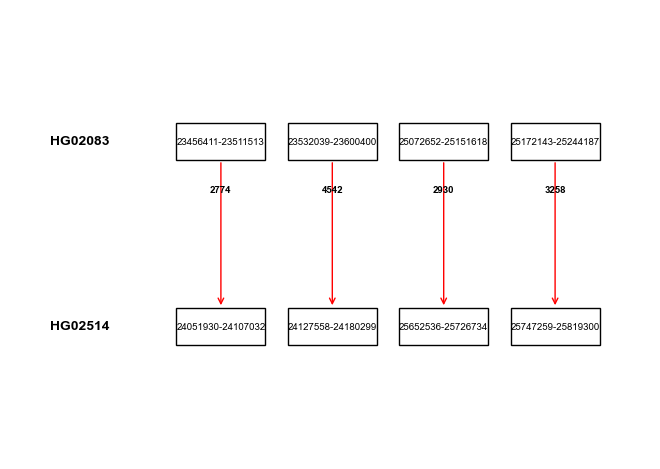

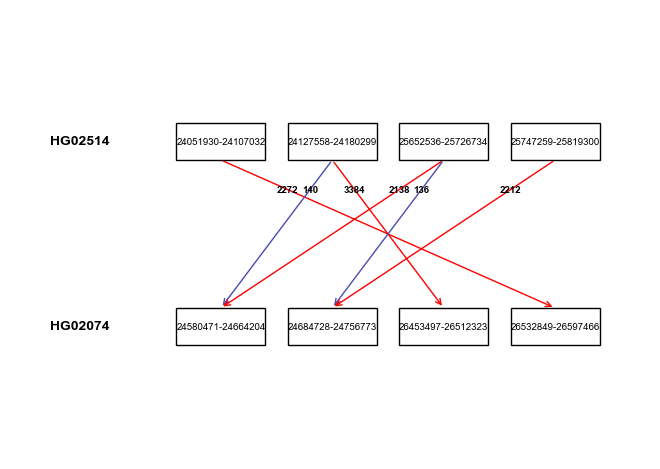

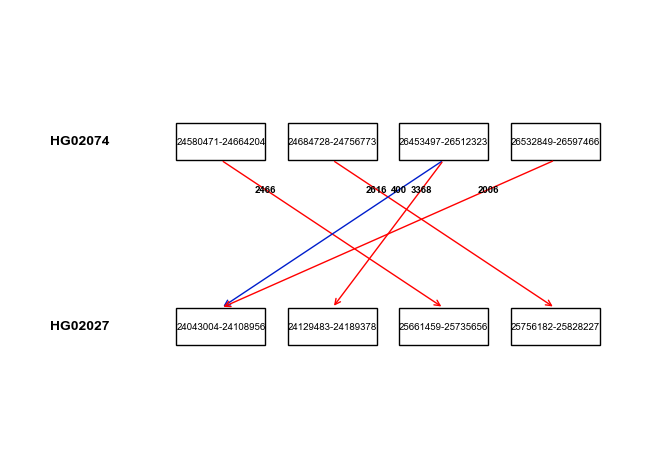

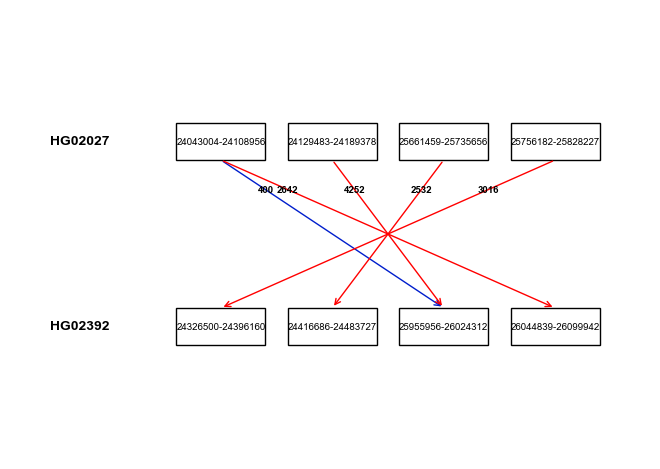

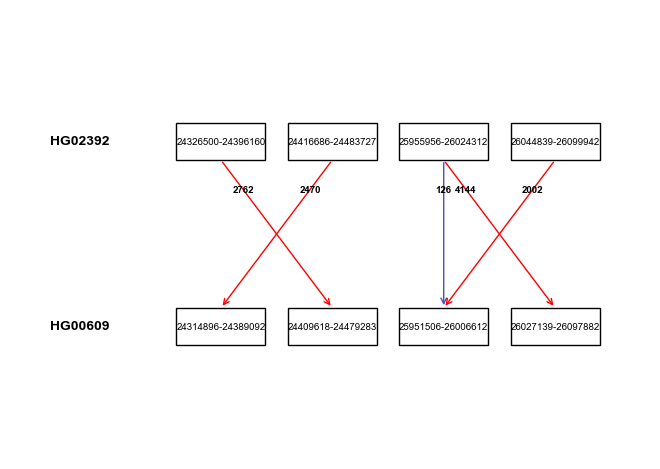

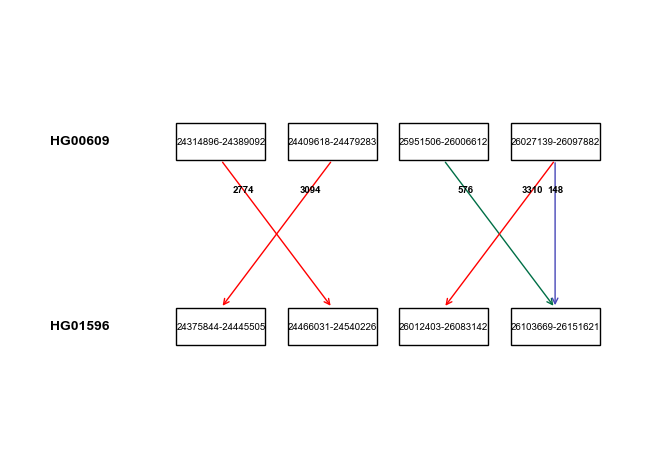

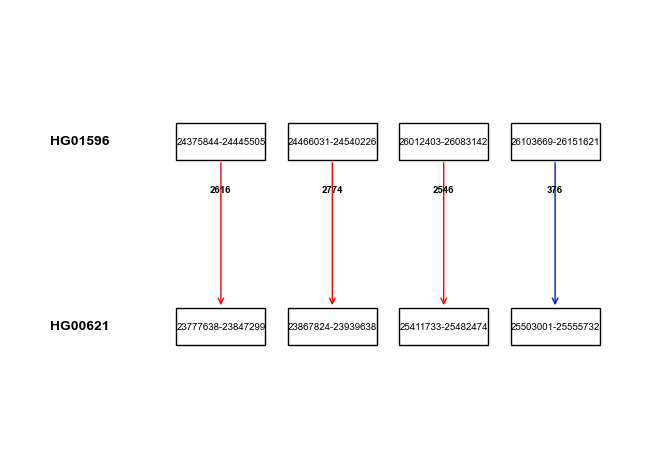

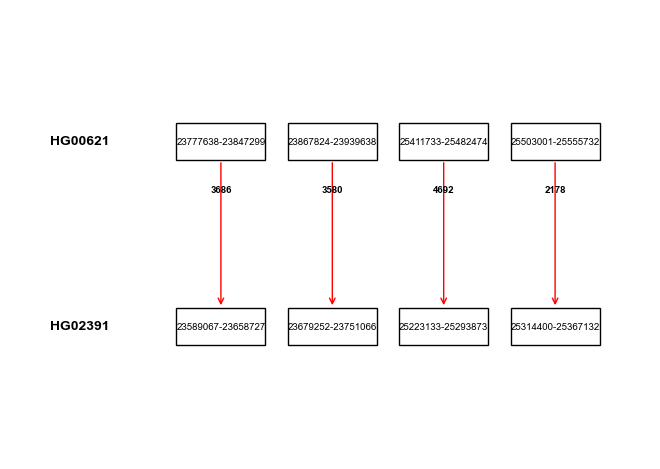

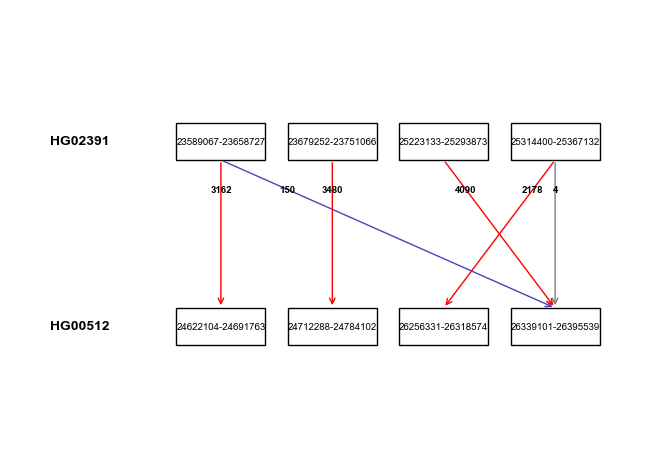

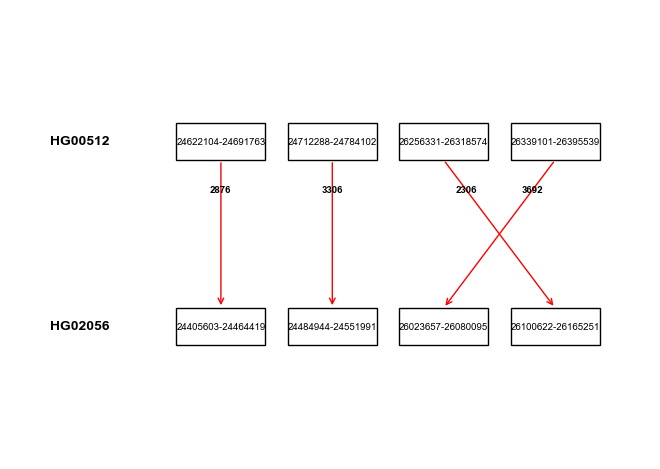

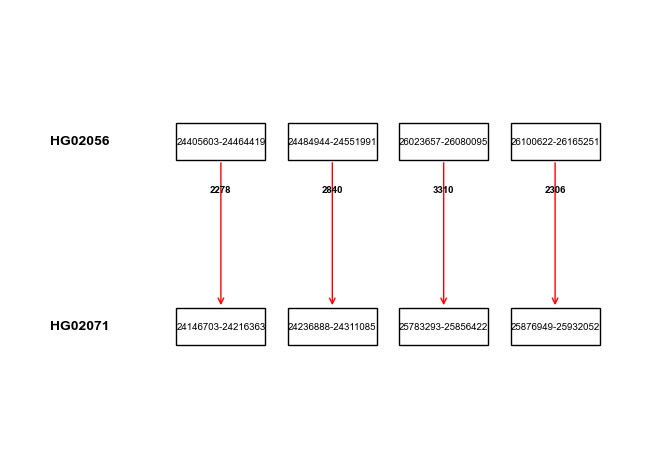

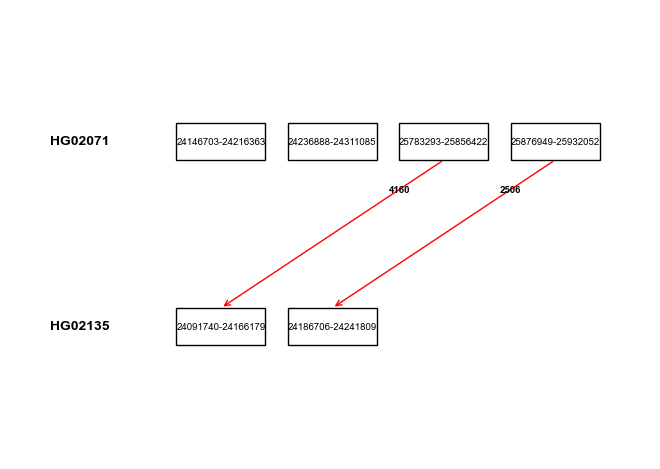

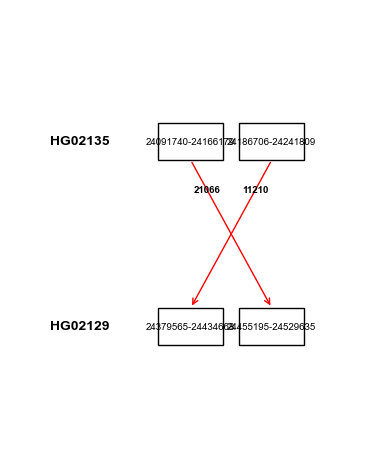

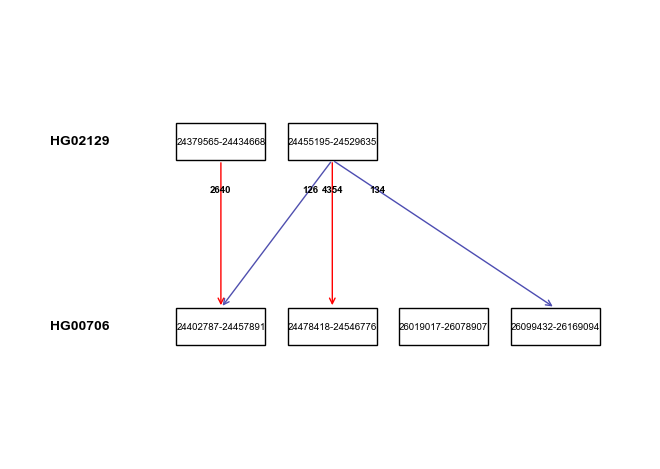

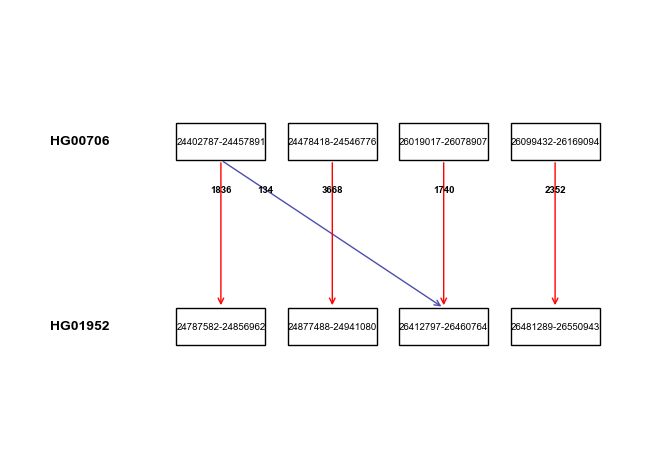

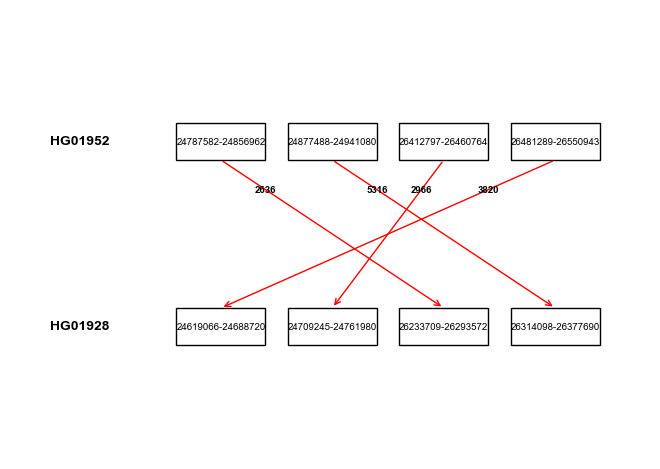

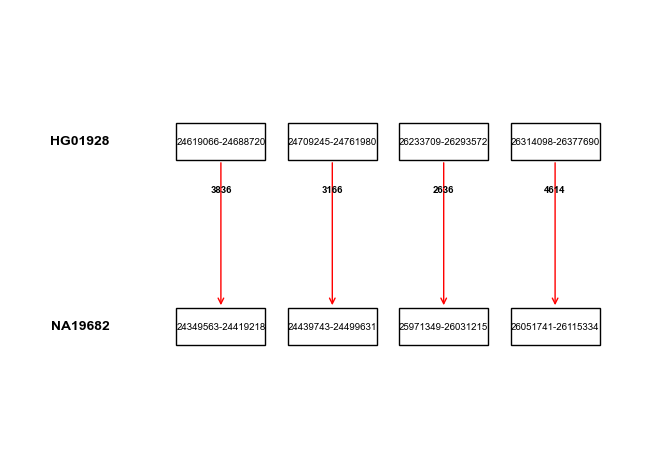

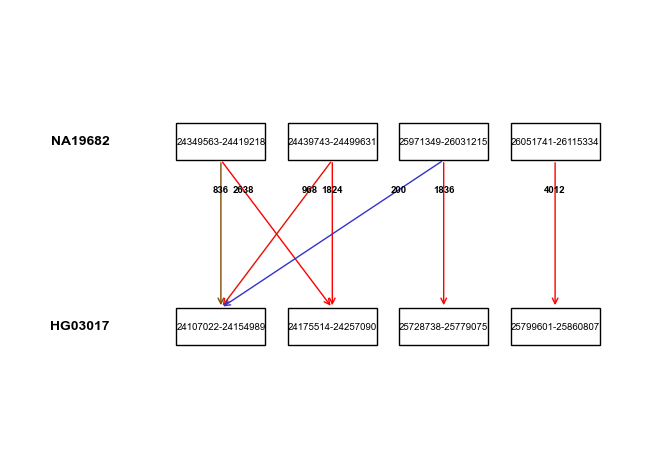

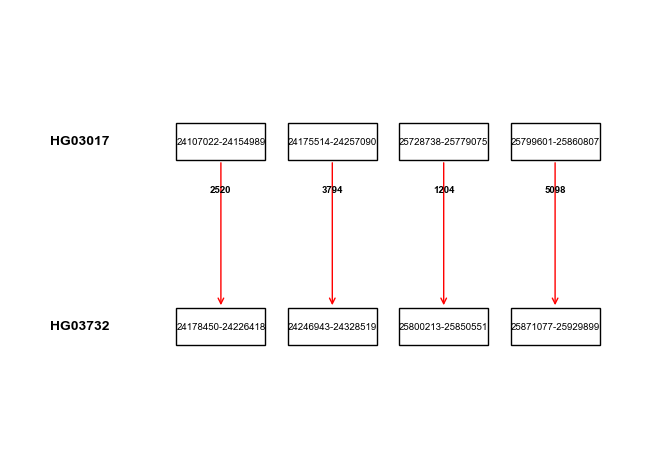

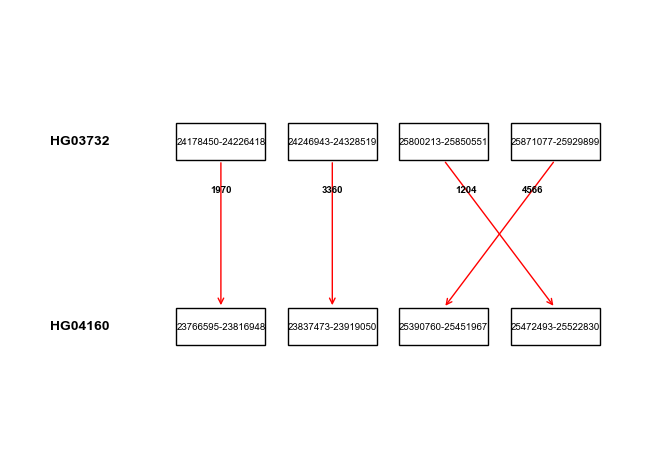

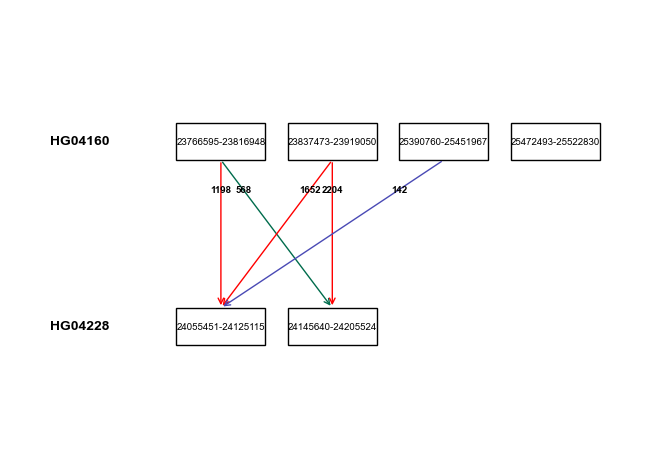

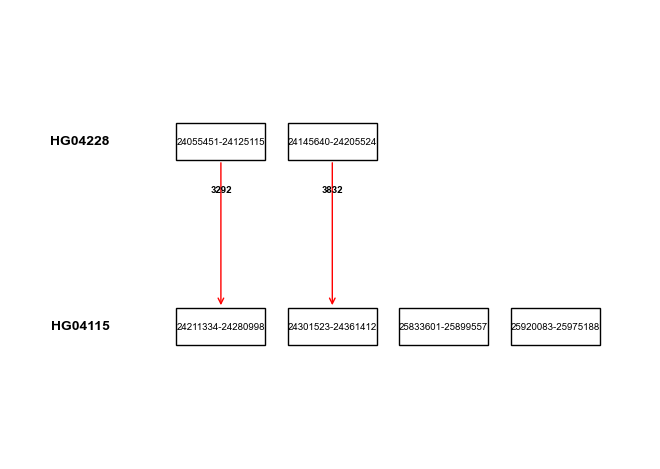

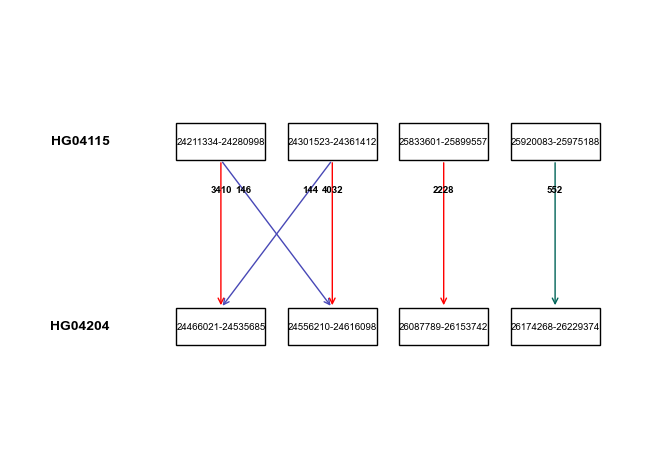

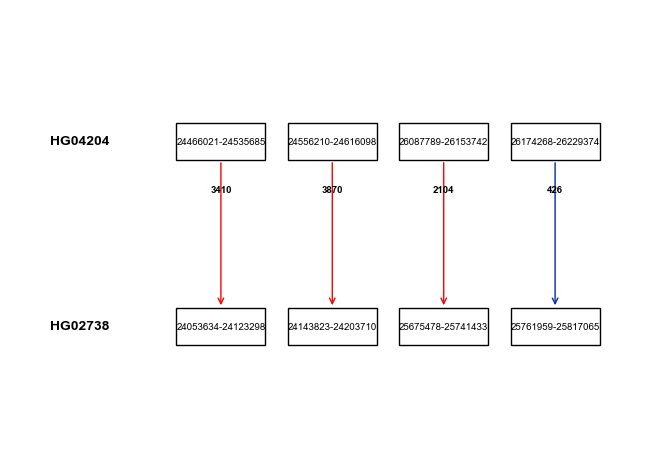

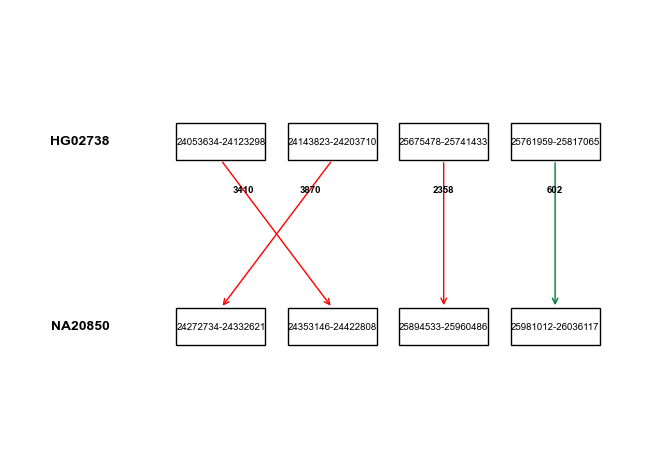

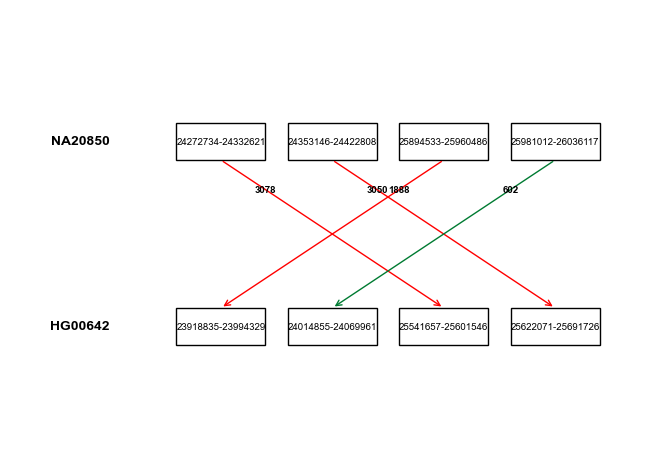

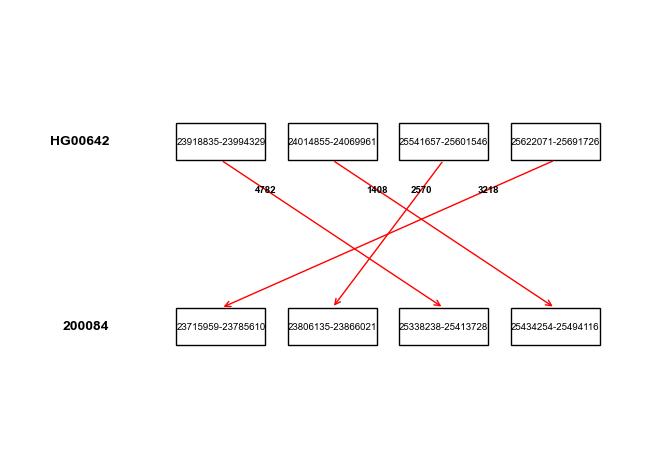

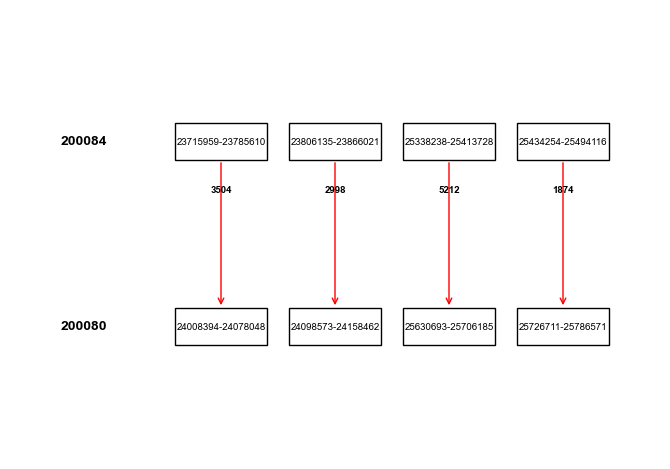

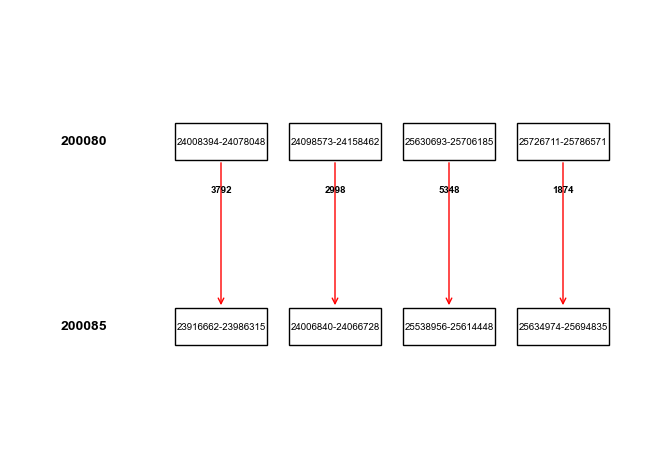

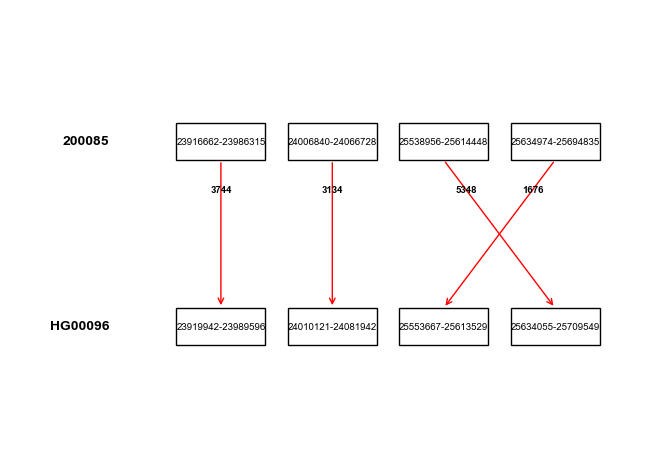

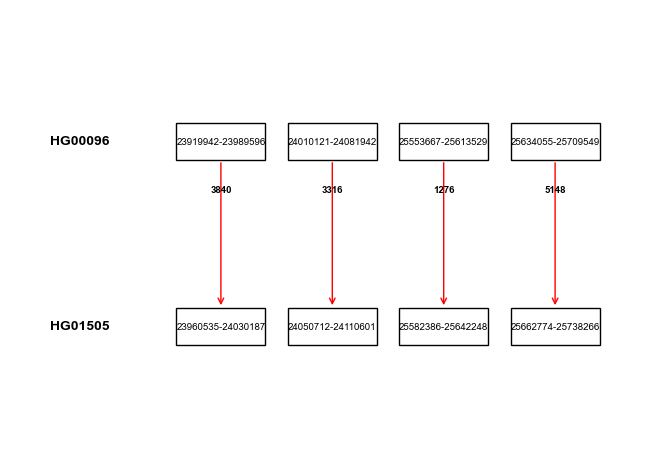

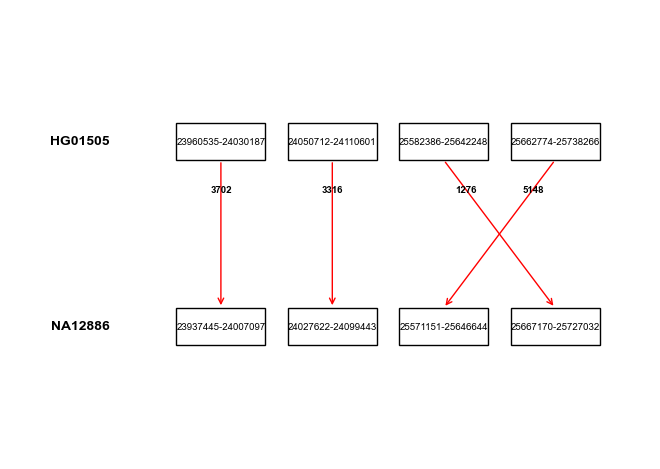

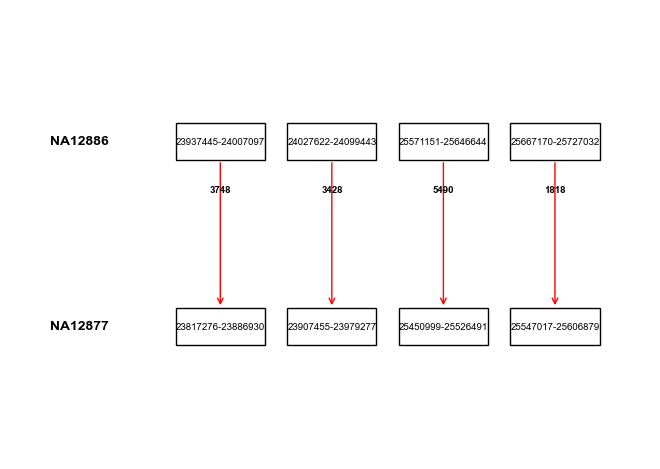

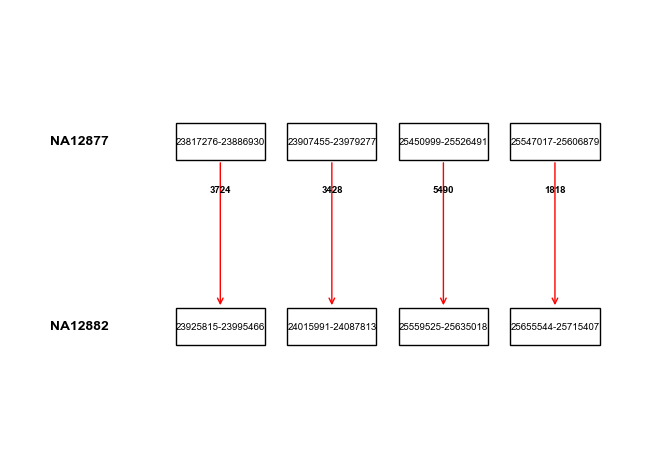

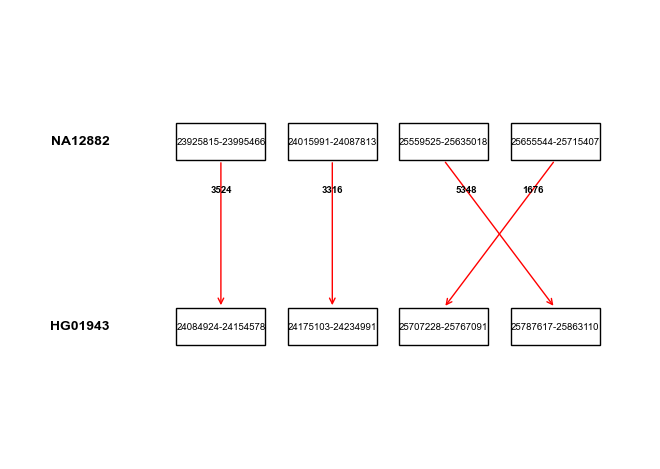

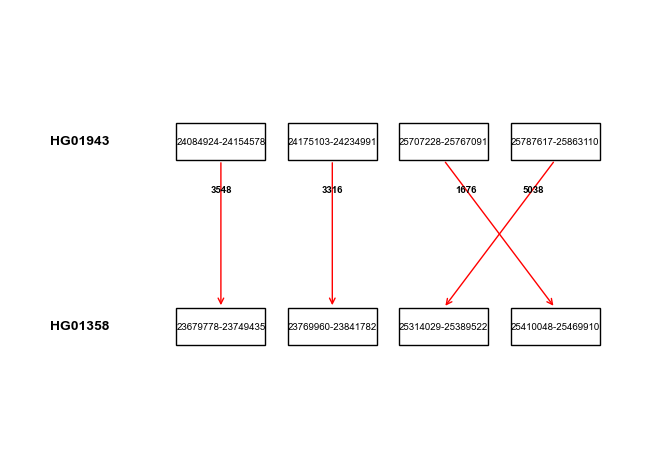

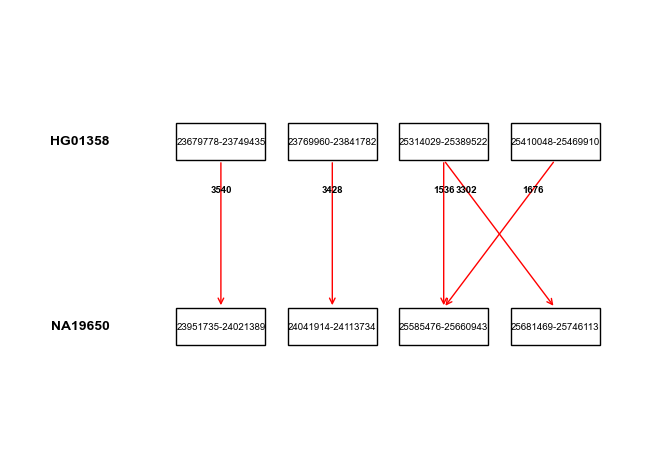

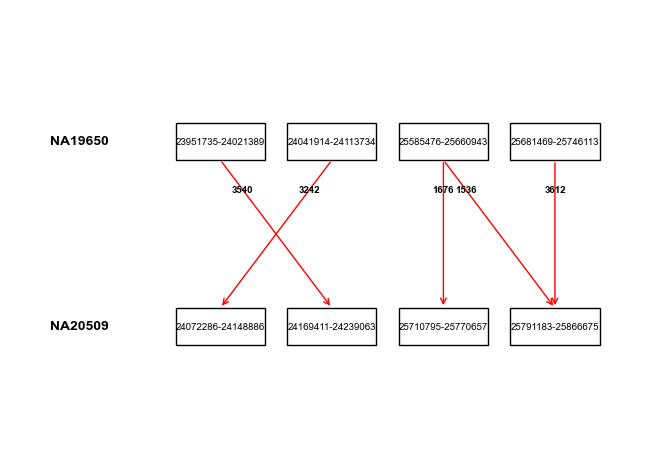

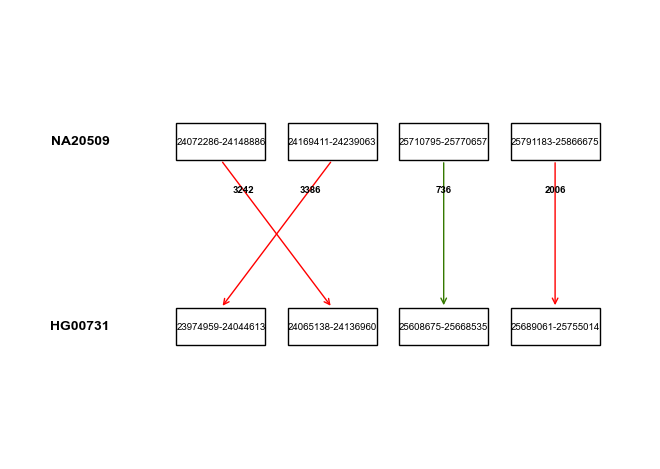

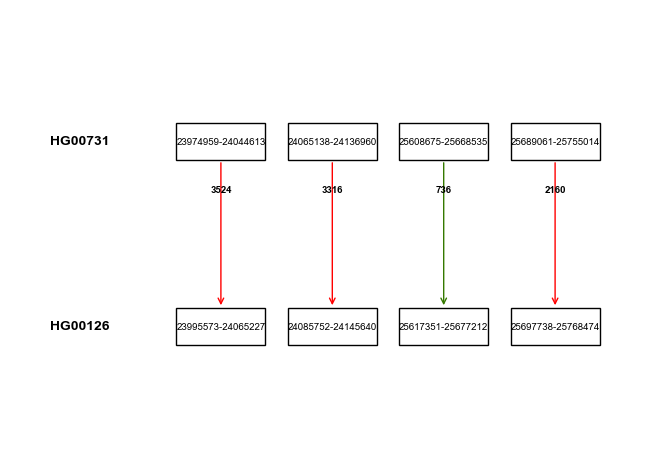

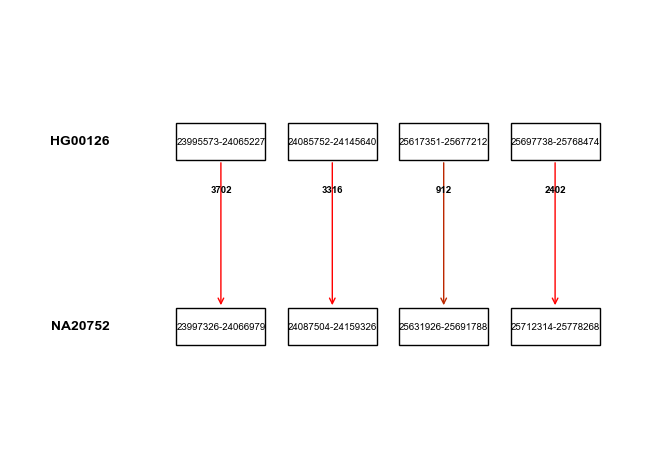

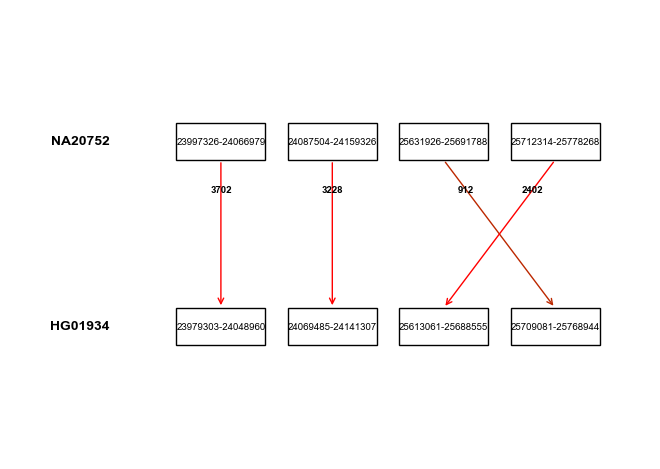

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

def parse_gene_string(gene_str):
    """
    Parse strings like 'HG01890_chrY:24817313-24879592'.
    Returns: (sample, contig, start, end)
    """
    sample_part, rest = gene_str.split("_", 1)
    contig, coords = rest.split(":", 1)
    start_str, end_str = coords.split("-", 1)
    return sample_part, contig, int(start_str), int(end_str)


def value_to_color(value, vmin=1, vmax=1000):
    """
    Map value in [vmin, vmax] to a color going:
      gray -> blue -> green -> red

    Returns an (r, g, b) tuple with each component in [0, 1].
    """
    v = float(value)

    if not np.isfinite(v):
        return (0.5, 0.5, 0.5)

    if vmax <= vmin:
        vmax = vmin + 1e-9

    v = np.clip(v, vmin, vmax)
    t = (v - vmin) / (vmax - vmin)  # in [0, 1]

    gray  = np.array([0.5, 0.5, 0.5], dtype=float)
    blue  = np.array([0.0, 0.0, 1.0], dtype=float)
    green = np.array([0.0, 0.6, 0.0], dtype=float)
    red   = np.array([1.0, 0.0, 0.0], dtype=float)

    if t < 1/3:
        u = t / (1/3)
        color = gray * (1 - u) + blue * u
    elif t < 2/3:
        u = (t - 1/3) / (1/3)
        color = blue * (1 - u) + green * u
    else:
        u = (t - 2/3) / (1/3)
        color = green * (1 - u) + red * u

    color = np.clip(color, 0.0, 1.0)
    return tuple(color)


def plot_sample_pair_unique(
    top_sample,
    bottom_sample,
    finalUniqueDF,
    figsize_scale=1.5,
    savepath=None,
    vmin=1,
    vmax=1000,
):
    """
    For a pair of samples, draw:
      - one box per unique gene in col 0 (top track)
      - one box per unique gene in col 1 (bottom track)

    Boxes:
      - all the same size in data coordinates
      - physical size is consistent across comparisons because
        figure width is linear in number of genes.

    Arrows:
      - connect top gene → bottom gene
      - labeled by col 2 (bold)
      - only drawn if value != 0
      - arrow color encodes value (vmin→gray, vmax→red via gray→blue→green→red)
    """

    sub = finalUniqueDF[
        finalUniqueDF[0].str.startswith(top_sample + "_")
        & finalUniqueDF[1].str.startswith(bottom_sample + "_")
    ].copy()

    if sub.empty:
        print(f"No rows for {top_sample}, {bottom_sample}")
        return

    sub[2] = sub[2].astype(float)

    top_parsed = sub[0].apply(parse_gene_string)
    bottom_parsed = sub[1].apply(parse_gene_string)

    sub["top_sample"] = [p[0] for p in top_parsed]
    sub["top_contig"] = [p[1] for p in top_parsed]
    sub["top_start"]  = [p[2] for p in top_parsed]
    sub["top_end"]    = [p[3] for p in top_parsed]

    sub["bottom_sample"] = [p[0] for p in bottom_parsed]
    sub["bottom_contig"] = [p[1] for p in bottom_parsed]
    sub["bottom_start"]  = [p[2] for p in bottom_parsed]
    sub["bottom_end"]    = [p[3] for p in bottom_parsed]

    top_genes = (
        sub[[0, "top_contig", "top_start", "top_end"]]
        .drop_duplicates(subset=0)
        .sort_values(["top_contig", "top_start", "top_end"])
        .reset_index(drop=True)
    )
    bottom_genes = (
        sub[[1, "bottom_contig", "bottom_start", "bottom_end"]]
        .drop_duplicates(subset=1)
        .sort_values(["bottom_contig", "bottom_start", "bottom_end"])
        .reset_index(drop=True)
    )

    top_positions = {row[0]: i for i, row in top_genes.iterrows()}       
    bottom_positions = {row[1]: i for i, row in bottom_genes.iterrows()} 

    n_top = len(top_genes)
    n_bottom = len(bottom_genes)
    n_cols = max(n_top, n_bottom)


    fig_width = max(1.0, n_cols * figsize_scale) 
    fig, ax = plt.subplots(figsize=(fig_width, 4))

    y_top = 1.0
    y_bottom = 0.0

    box_width = 0.8      
    box_height = 0.2

    for i, row in top_genes.iterrows():
        gene_str = row[0]
        x = top_positions[gene_str]

        ax.add_patch(Rectangle(
            (x - box_width/2, y_top - box_height/2),
            box_width,
            box_height,
            edgecolor="black",
            facecolor="none",
            linewidth=1
        ))
        label = f"{row['top_start']}-{row['top_end']}"
        ax.text(x, y_top, label, ha="center", va="center", fontsize=7)

    for i, row in bottom_genes.iterrows():
        gene_str = row[1]
        x = bottom_positions[gene_str]

        ax.add_patch(Rectangle(
            (x - box_width/2, y_bottom - box_height/2),
            box_width,
            box_height,
            edgecolor="black",
            facecolor="none",
            linewidth=1
        ))
        label = f"{row['bottom_start']}-{row['bottom_end']}"
        ax.text(x, y_bottom, label, ha="center", va="center", fontsize=7)

    for _, row in sub.iterrows():
        value = row[2]

        if value == 0:
            continue

        top_gene_str = row[0]
        bottom_gene_str = row[1]

        x1 = top_positions[top_gene_str]
        x2 = bottom_positions[bottom_gene_str]

        x_start, y_start = x1, y_top - box_height/2
        x_end, y_end = x2, y_bottom + box_height/2

        arrow_color = value_to_color(value, vmin=vmin, vmax=vmax)

        arrow = FancyArrowPatch(
            (x_start, y_start),
            (x_end, y_end),
            arrowstyle="->",
            mutation_scale=10,
            linewidth=1,
            color=arrow_color,
            connectionstyle="arc3,rad=0.0"  
        )
        ax.add_patch(arrow)

        t_lab = 0.2 
        x_lab = x_start + t_lab * (x_end - x_start)
        y_lab = y_start + t_lab * (y_end - y_start)

        ax.text(
            x_lab,
            y_lab,
            str(int(value)),
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold"  
        )

    ax.text(
        -1, y_top, top_sample,
        ha="right", va="center",
        fontsize=10, fontweight="bold"
    )
    ax.text(
        -1, y_bottom, bottom_sample,
        ha="right", va="center",
        fontsize=10, fontweight="bold"
    )

    ax.set_xlim(-1.5, n_cols - 0.5)
    ax.set_ylim(-0.5, 1.5)
    ax.axis("off")

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


for top_sample, bottom_sample in sampleCombinations:
    plot_sample_pair_unique(top_sample, bottom_sample, finalUniqueDF)

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np
import pandas as pd
from collections import defaultdict


def parse_gene_string(gene_str):
    """
    Parse strings like 'HG01890_chrY:24817313-24879592'.
    Returns: (sample, contig, start, end)
    """
    sample_part, rest = gene_str.split("_", 1)
    contig, coords = rest.split(":", 1)
    start_str, end_str = coords.split("-", 1)
    return sample_part, contig, int(start_str), int(end_str)


def value_to_color(value, vmin=1, vmax=1000):
    """
    Map value in [vmin, vmax] to a color going:
      gray -> blue -> green -> red

    v >= vmax (>=1000) will be clamped to red.
    Returns (r, g, b) in [0, 1].
    """
    v = float(value)

    if not np.isfinite(v):
        return (0.5, 0.5, 0.5)

    vmax = max(vmax, vmin + 1e-9)

    v = np.clip(v, vmin, vmax)
    t = (v - vmin) / (vmax - vmin)  # 0..1

    gray  = np.array([0.5, 0.5, 0.5], dtype=float)
    blue  = np.array([0.0, 0.0, 1.0], dtype=float)
    green = np.array([0.0, 0.6, 0.0], dtype=float)
    red   = np.array([1.0, 0.0, 0.0], dtype=float)

    if t < 1/3:
        u = t / (1/3)
        color = gray * (1 - u) + blue * u
    elif t < 2/3:
        u = (t - 1/3) / (1/3)
        color = blue * (1 - u) + green * u
    else:
        u = (t - 2/3) / (1/3)
        color = green * (1 - u) + red * u

    color = np.clip(color, 0.0, 1.0)
    return tuple(color)


def build_sample_gene_tables(finalUniqueDF):
    """
    Build per-sample gene lists (one row per gene).
    Returns:
      sample_genes: dict[sample] -> list of (gene_str, contig, start, end)
    """
    sample_genes = defaultdict(dict)  

    for col in [0, 1]:
        for gene_str in finalUniqueDF[col].unique():
            sample, contig, start, end = parse_gene_string(gene_str)
            if gene_str not in sample_genes[sample]:
                sample_genes[sample][gene_str] = (contig, start, end)

    sample_genes_sorted = {}
    for sample, genes_dict in sample_genes.items():
        genes_list = []
        for gene_str, (contig, start, end) in genes_dict.items():
            genes_list.append((gene_str, contig, start, end))
        genes_list.sort(key=lambda x: (x[1], x[2], x[3]))  # contig, start, end
        sample_genes_sorted[sample] = genes_list

    return sample_genes_sorted


def plot_all_samples_network(
    geneCoordinateKmerCountDict,
    sampleCombinations,
    finalUniqueDF,
    fig_width_per_col=1.5,
    row_height=2.5,
    vmin=1,
    vmax=1000,
    savepath=None,
):
    """
    One big figure:

    - Each sample appears ONCE as a horizontal row of gene boxes.
    - Boxes are same size across whole figure.
    - For each row in finalUniqueDF:
        col0 gene -> col1 gene arrow.
        Arrow starts from BOTTOM of source box and ends at TOP of target box.
    - Arrow color encodes value (1..1000); >=1000 is capped at red.
    """

    finalUniqueDF = finalUniqueDF.copy()
    finalUniqueDF[2] = finalUniqueDF[2].astype(float)

    ordered_samples = []
    for a, b in sampleCombinations:
        if a not in ordered_samples:
            ordered_samples.append(a)
        if b not in ordered_samples:
            ordered_samples.append(b)

    sample_genes = build_sample_gene_tables(finalUniqueDF)

    ordered_samples = [s for s in ordered_samples if s in sample_genes]

    n_samples = len(ordered_samples)
    if n_samples == 0:
        print("No samples with genes to plot.")
        return

    max_genes = max(len(sample_genes[s]) for s in ordered_samples)

    step_y = 2.0
    sample_y = {}
    for i, sample in enumerate(ordered_samples):
        sample_y[sample] = (n_samples - 1 - i) * step_y

    gene_pos = {}  
    for sample in ordered_samples:
        genes_list = sample_genes[sample]
        for idx, (gene_str, contig, start, end) in enumerate(genes_list):
            x = idx  
            y = sample_y[sample]
            gene_pos[gene_str] = (x, y)

    fig_width = max(4, max_genes * fig_width_per_col)
    fig_height = max(4, n_samples * row_height)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    box_width = 0.8
    box_height = 0.4

    for sample in ordered_samples:
        y = sample_y[sample]
        genes_list = sample_genes[sample]

        ax.text(
            -1,
            y,
            sample,
            ha="right",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

        for idx, (gene_str, contig, start, end) in enumerate(genes_list):
            x = idx
            ax.add_patch(Rectangle(
                (x - box_width / 2, y - box_height / 2),
                box_width,
                box_height,
                edgecolor="black",
                facecolor="none",
                linewidth=1,
            ))
            coord_label = f"{start}-{end}"
            ax.text(
                x,
                y,
                genePSVDict[sample+"_chrY:"+str(coord_label)]+": "+str(geneCoordinateKmerCountDict[sample][sample+"_chrY:"+str(coord_label)]),
                ha="center",
                va="center",
                fontsize=6,
            )

    for _, row in finalUniqueDF.iterrows():
        v = float(row[2])
        if v == 0:
            continue

        gene_src = row[0]
        gene_tgt = row[1]

        if gene_src not in gene_pos or gene_tgt not in gene_pos:
            continue  # safety

        x_src, y_src_center = gene_pos[gene_src]
        x_tgt, y_tgt_center = gene_pos[gene_tgt]

        x_start = x_src
        y_start = y_src_center - box_height / 2
        x_end = x_tgt
        y_end = y_tgt_center + box_height / 2

        color = value_to_color(v, vmin=vmin, vmax=vmax)  

        arrow = FancyArrowPatch(
            (x_start, y_start),
            (x_end, y_end),
            arrowstyle="->",
            mutation_scale=10,
            linewidth=1,
            color=color,
            connectionstyle="arc3,rad=0.0",
        )
        ax.add_patch(arrow)

        t = 0.2
        x_lab = x_start + t * (x_end - x_start)
        y_lab = y_start + t * (y_end - y_start)

        ax.text(
            x_lab,
            y_lab,
            str(int(v)),
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
        )

    ax.set_xlim(-1.5, max_genes - 0.5)
    ymin = min(sample_y.values()) - 1.0
    ymax = max(sample_y.values()) + 1.0
    ax.set_ylim(ymin, ymax)
    ax.axis("off")

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        plt.close(fig)
    else:
        plt.show()

In [28]:
plot_all_samples_network(sampleCoordinates,
    sampleCombinations,
    finalUniqueDF,
    fig_width_per_col=1.5,
    row_height=.7,
    vmin=1,
    vmax=5000, savepath='/DAZ_UniqueKmers_100_Jan222026.pdf'
)

In [29]:
plot_all_samples_network(sampleCoordinates,
    sampleCombinations,
    finalGCDF,
    fig_width_per_col=1.5,
    row_height=.7,
    vmin=1,
    vmax=5000, savepath='/DAZ_MultiHitKmers_Jan222026_100.pdf'
)

In [42]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np
import pandas as pd
from collections import defaultdict


def parse_gene_string(gene_str):
    sample_part, rest = gene_str.split("_", 1)
    contig, coords = rest.split(":", 1)
    start_str, end_str = coords.split("-", 1)
    return sample_part, contig, int(start_str), int(end_str)


def value_to_color(value, vmin=1, vmax=1000):
    v = float(value)
    if not np.isfinite(v):
        return (0.5, 0.5, 0.5)

    vmax = max(vmax, vmin + 1e-9)
    v = np.clip(v, vmin, vmax)
    t = (v - vmin) / (vmax - vmin)

    gray  = np.array([0.5, 0.5, 0.5], dtype=float)
    blue  = np.array([0.0, 0.0, 1.0], dtype=float)
    green = np.array([0.0, 0.6, 0.0], dtype=float)
    red   = np.array([1.0, 0.0, 0.0], dtype=float)

    if t < 1/3:
        u = t / (1/3)
        color = gray * (1 - u) + blue * u
    elif t < 2/3:
        u = (t - 1/3) / (1/3)
        color = blue * (1 - u) + green * u
    else:
        u = (t - 2/3) / (1/3)
        color = green * (1 - u) + red * u

    return tuple(np.clip(color, 0.0, 1.0))


def build_sample_gene_tables(finalUniqueDF):
    sample_genes = defaultdict(dict)

    for col in [0, 1]:
        for gene_str in finalUniqueDF[col].unique():
            sample, contig, start, end = parse_gene_string(gene_str)
            if gene_str not in sample_genes[sample]:
                sample_genes[sample][gene_str] = (contig, start, end)

    sample_genes_sorted = {}
    for sample, genes_dict in sample_genes.items():
        genes_list = [(gene_str, *coords) for gene_str, coords in genes_dict.items()]
        genes_list.sort(key=lambda x: (x[1], x[2], x[3]))  
        sample_genes_sorted[sample] = genes_list

    return sample_genes_sorted


def plot_all_samples_network_chunked_with_overlap(
    geneCoordinateKmerCountDict,
    sampleCombinations,
    finalUniqueDF,
    *,
    fig_width_per_col=1.5,
    row_height=2.5,
    vmin=1,
    vmax=1000,
    savepath_prefix=None,
    Npages=2,
    overlap_samples=1,  
):
    """
    Chunked (multi-page) plot, BUT with overlap between consecutive pages so
    cross-page arrows can still be drawn (because the shared sample exists on both pages).

    Example with overlap_samples=1:
      Page1: A B C D
      Page2: D E F G
      Page3: G H I J
    """

    finalUniqueDF = finalUniqueDF.copy()
    finalUniqueDF[2] = finalUniqueDF[2].astype(float)
    ordered_samples = []
    for a, b in sampleCombinations:
        if a not in ordered_samples:
            ordered_samples.append(a)
        if b not in ordered_samples:
            ordered_samples.append(b)

    sample_genes = build_sample_gene_tables(finalUniqueDF)
    ordered_samples = [s for s in ordered_samples if s in sample_genes]

    n_samples = len(ordered_samples)
    if n_samples == 0:
        print("No samples with genes to plot.")
        return

    global_max_genes = max(len(sample_genes[s]) for s in ordered_samples)

    per_page = math.ceil(n_samples / Npages) if Npages else n_samples
    per_page = max(1, per_page)

    overlap_samples = max(0, int(overlap_samples))
    if overlap_samples >= per_page:
        overlap_samples = max(0, per_page - 1)  

    stride = per_page - overlap_samples 

    page_windows = []
    start = 0
    while start < n_samples:
        end = min(n_samples, start + per_page)
        page_windows.append((start, end))
        if end == n_samples:
            break
        start = start + stride

    for page_idx, (s0, s1) in enumerate(page_windows, start=1):
        page_samples = ordered_samples[s0:s1]
        n_page = len(page_samples)
        if n_page == 0:
            continue

        step_y = 2.0
        sample_y = {sample: (n_page - 1 - i) * step_y for i, sample in enumerate(page_samples)}

        gene_pos = {}
        for sample in page_samples:
            for idx, (gene_str, contig, start_gene, end_gene) in enumerate(sample_genes[sample]):
                gene_pos[gene_str] = (idx, sample_y[sample])

        fig_width = max(4, global_max_genes * fig_width_per_col)
        fig_height = max(4, n_page * row_height)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        box_width = 0.8
        box_height = 0.4

        for sample in page_samples:
            y = sample_y[sample]
            ax.text(-1, y, sample, ha="right", va="center", fontsize=10, fontweight="bold")

            for idx, (gene_str, contig, gstart, gend) in enumerate(sample_genes[sample]):
                x = idx
                ax.add_patch(Rectangle(
                    (x - box_width / 2, y - box_height / 2),
                    box_width,
                    box_height,
                    edgecolor="black",
                    facecolor="none",
                    linewidth=1,
                ))

                coord_label = f"{gstart}-{gend}"
                key = sample + "_chrY:" + str(coord_label)

                ax.text(
                    x, y,
                    str(genePSVDict[key]) + ": " + str(geneCoordinateKmerCountDict[sample][key]),
                    ha="center", va="center", fontsize=6
                )

        for _, row in finalUniqueDF.iterrows():
            v = float(row[2])
            if v == 0:
                continue

            gene_src = row[0]
            gene_tgt = row[1]
            if gene_src not in gene_pos or gene_tgt not in gene_pos:
                continue

            x_src, y_src_center = gene_pos[gene_src]
            x_tgt, y_tgt_center = gene_pos[gene_tgt]

            x_start = x_src
            y_start = y_src_center - box_height / 2
            x_end   = x_tgt
            y_end   = y_tgt_center + box_height / 2

            color = value_to_color(v, vmin=vmin, vmax=vmax)
            ax.add_patch(FancyArrowPatch(
                (x_start, y_start),
                (x_end, y_end),
                arrowstyle="->",
                mutation_scale=10,
                linewidth=1,
                color=color,
                connectionstyle="arc3,rad=0.0",
            ))

            t = 0.2
            x_lab = x_start + t * (x_end - x_start)
            y_lab = y_start + t * (y_end - y_start)
            ax.text(x_lab, y_lab, str(int(v)), ha="center", va="center",
                    fontsize=7, fontweight="bold")

        ax.set_xlim(-1.5, global_max_genes - 0.5)
        ymin = min(sample_y.values()) - 1.0
        ymax = max(sample_y.values()) + 1.0
        ax.set_ylim(ymin, ymax)
        ax.axis("off")
        plt.tight_layout()

        if savepath_prefix:
            out_jpg = f"{savepath_prefix}_page{page_idx}.jpg"
            out_pdf = f"{savepath_prefix}_page{page_idx}.pdf"
            fig.savefig(out_jpg, bbox_inches="tight", dpi=300)
            fig.savefig(out_pdf, bbox_inches="tight")
            plt.close(fig)
            print("Saved", out_jpg)
        else:
            plt.show()


In [43]:
plot_all_samples_network_chunked_with_overlap(
    sampleCoordinates,
    sampleCombinations,
    finalUniqueDF,
    Npages=4,
    overlap_samples=1,
    row_height=0.6,
    vmax=5000,
    savepath_prefix="/network_plot"
)


Saved /network_plot_page1.jpg
Saved /network_plot_page2.jpg
Saved /network_plot_page3.jpg
Saved /network_plot_page4.jpg
Saved /network_plot_page5.jpg
